<a href="https://colab.research.google.com/github/Khyati-33/QKD-Routing/blob/main/GNNPPOTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
from gymnasium import spaces
import networkx as nx
from scipy.special import comb
from math import comb as mcomb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import deque
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)
print("✓ All imports OK")

✓ All imports OK


## Integrating RL4CO for Pre-trained Models

To leverage transfer learning with `RL4CO`, we first need to install the library. Then, we will explore how to load a pre-trained attention model and integrate its encoder into our `GNNActorCritic`.

In [2]:
%%capture
!pip install rl4co

Now that `RL4CO` is installed, you can import its components. For QKD routing, models pre-trained on combinatorial optimization problems like TSP or VRP could be good candidates. `RL4CO` typically provides attention-based models.

Here's an example of how you might load a pre-trained model. Note that you would need to identify a pre-trained model within `RL4CO` that best suits your graph structure and problem type. For demonstration, we'll use a conceptual `AttentionModel`.

In [3]:
# Cell removed: RL4CO model loading is no longer relevant after removing RL4COBasedGNNEncoder.

### Adapting the GNNEncoder with RL4CO's Encoder

Your `GNNEncoder` is responsible for producing node embeddings. `RL4CO`'s attention models also have powerful encoders that process graph-structured data. The idea is to replace or augment your `GNNEncoder` with the encoder component from a pre-trained `RL4CO` model.

Here's how you might conceptualize this. You would extract the encoder part of the `RL4CO` model and potentially fine-tune it. The exact implementation depends on the specific `RL4CO` model architecture. Typically, `RL4CO` models handle node features and adjacency directly.

In [4]:
def binary_entropy(p):
    p = np.clip(p, 1e-12, 1-1e-12)
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

class FiberLink:
    def __init__(self, node_i, node_j, length_km,
                 alpha_db_per_km=0.2, eta_d=0.6,
                 dark_count=1e-6, visibility=0.98,
                 pulse_rate_MHz=100, f_ec=1.16,
                 epsilon_sec=1e-10, n_block=1e6):
        self.node_i, self.node_j = node_i, node_j
        self.L = length_km * 1e3
        self.alpha = alpha_db_per_km
        self.eta_d = eta_d
        self.dark_count = dark_count
        self.visibility = visibility
        self.pulse_rate = pulse_rate_MHz * 1e6
        self.f_ec = f_ec
        self.epsilon_sec = epsilon_sec
        self.n_block = n_block

    def link_type(self): return 'fiber'

    def transmittance(self, conditions):
        eta_fiber = 10**(-self.alpha * self.L/1e3 / 10)
        return eta_fiber * 0.9 * self.eta_d

    def noise_rate(self, conditions):
        return self.dark_count

    def sample_conditions(self, time):
        return {'temperature_k': 293 + 3*np.sin(2*np.pi*time/86400)}

    def QBER(self, conditions):
        eta = self.transmittance(conditions)
        d   = self.noise_rate(conditions)
        e_opt = (1 - self.visibility) / 2
        e_noise = d / (eta + d + 1e-12)
        return float(np.clip(e_opt + e_noise, 0, 0.5))

    def SKR_finite(self, conditions):
        eta = self.transmittance(conditions)
        e   = self.QBER(conditions)
        if e >= 0.11: return 0.0
        delta = 7 * np.sqrt(np.log2(2.0 / self.epsilon_sec))
        corr  = delta / np.sqrt(self.n_block)
        r = max(0., eta*(1-(1+self.f_ec)*binary_entropy(e)) - corr)
        return r * self.pulse_rate


class FSOLink:
    def __init__(self, node_i, node_j, length_km,
                 wavelength_nm=785, beam_waist_mm=80,
                 receiver_radius_mm=200, eta_d=0.6,
                 dark_count=1e-6, visibility=0.98,
                 pulse_rate_MHz=100, f_ec=1.16,
                 epsilon_sec=1e-10, n_block=1e6,
                 pointing_error_rad=1e-6, H_sun=1.5e3):
        self.node_i, self.node_j = node_i, node_j
        self.L = length_km * 1e3
        self.lambda_m = wavelength_nm * 1e-9
        self.W0 = beam_waist_mm * 1e-3
        self.R  = receiver_radius_mm * 1e-3
        self.eta_d = eta_d
        self.dark_count = dark_count
        self.visibility = visibility
        self.pulse_rate = pulse_rate_MHz * 1e6
        self.f_ec = f_ec
        self.epsilon_sec = epsilon_sec
        self.n_block = n_block
        self.pointing_error = pointing_error_rad
        self.H_sun = H_sun

    def link_type(self): return 'fso'

    def transmittance(self, conditions):
        Cn2     = conditions.get('Cn2', 1e-14)
        eta_atm = conditions.get('eta_atm', 0.9)
        # Diffraction
        z_R  = np.pi * self.W0**2 / self.lambda_m
        W_L  = self.W0 * np.sqrt(1 + (self.L/z_R)**2)
        eta_diff = 1 - np.exp(-2*self.R**2 / W_L**2)
        # Turbulence (weak-fluctuation Strehl)
        k = 2*np.pi / self.lambda_m
        sigma_R2 = 1.23 * Cn2 * k**(7/6) * self.L**(11/6)
        eta_turb = np.exp(-sigma_R2 / 2)
        # Pointing
        theta_div = self.lambda_m / (np.pi * self.W0)
        eta_point = np.exp(-self.pointing_error**2 / theta_div**2)
        return float(np.clip(
            eta_diff * eta_atm * eta_turb * eta_point * 0.85 * 0.5 * self.eta_d,
            0, 1))

    def noise_rate(self, conditions):
        sun = conditions.get('sun_elevation', 0.0)
        h, c = 6.626e-34, 3e8
        E_ph = h*c / self.lambda_m
        A_r  = np.pi * self.R**2
        R_bg = (self.H_sun * sun * 0.2 * self.eta_d * 0.5 *
                A_r * 0.1e-9 * (100e-6)**2 * 0.5e-9 / E_ph)
        return self.dark_count + R_bg

    def sample_conditions(self, time):
        hour = (time / 3600) % 24
        # Stochastic Gamma-Gamma fading: sample Cn2 each timestep
        Cn2_mean = 1e-14 * np.exp(-((hour-13)**2)/18)
        Cn2_mean = max(Cn2_mean, 1e-17)
        Cn2 = float(np.random.lognormal(np.log(Cn2_mean), 0.5))
        eta_atm = float(np.clip(np.random.normal(0.9, 0.02), 0.1, 1.0))
        sun_elev = float(max(0, np.sin(np.pi*(hour-6)/12)))
        k = 2*np.pi / self.lambda_m
        return {
            'Cn2': Cn2,
            'eta_atm': eta_atm,
            'sun_elevation': sun_elev,
            'time_of_day': hour,
            'sigma_R2': 1.23*Cn2*k**(7/6)*self.L**(11/6),
        }

    def QBER(self, conditions):
        eta = self.transmittance(conditions)
        d   = self.noise_rate(conditions)
        e_opt = (1 - self.visibility) / 2
        e_noise = d / (eta + d + 1e-12)
        return float(np.clip(e_opt + e_noise, 0, 0.5))

    def SKR_finite(self, conditions):
        eta = self.transmittance(conditions)
        e   = self.QBER(conditions)
        if e >= 0.11: return 0.0
        delta = 7 * np.sqrt(np.log2(2.0 / self.epsilon_sec))
        corr  = delta / np.sqrt(self.n_block)
        r = max(0., eta*(1-(1+self.f_ec)*binary_entropy(e)) - corr)
        return r * self.pulse_rate

print("✓ Physics layer loaded")

✓ Physics layer loaded


In [5]:
def total_chain_noise(Q: float, p: int) -> float:
    """
    Finite-key total noise for STN chain with p relay nodes (p+1 links).
    Eq.30: w(q) = sum_{i=0}^{floor((p+1)/2)-1} C(p+1,2i+1)*Q^(2i+1)*(1-Q)^(p-2i)
    """
    n_links = p + 1
    w = 0.0
    for i in range(n_links // 2):
        w += mcomb(n_links, 2*i+1) * (Q**(2*i+1)) * ((1-Q)**(n_links-2*i-1))
    return w

def stn_noise_tolerance(p: int) -> float:
    """Max per-link Q such that w(q) < 0.11 (security limit)."""
    from scipy.optimize import brentq
    try:
        return brentq(lambda Q: total_chain_noise(Q, p) - 0.11, 0, 0.499)
    except:
        return 0.0


class QKDNetwork:
    """
    5-node hybrid fiber/FSO network with STN relay nodes.

    Topology:
      Alice(0) --fiber-- STN_1(1) --FSO-- STN_2(2) --fiber-- STN_3(3) --FSO-- Bob(4)
                              \\                                    /
                               +----------fiber-----------------+
    """
    def __init__(self, config=None):
        self.config = config or self._default_config()
        self.links  = self._build_links()
        self.graph  = self._build_graph()
        self.pool_capacity = 1e6   # bits per link
        self.key_pools = {lk: self.pool_capacity for lk in self.links}
        # Pre-enumerate candidate paths (k-shortest)
        self.candidate_paths = self._enumerate_paths(
            source='A', destination='D', k=8
        )

    def _default_config(self):
        return {
            'nodes': ['A','S1','S2','S3','D'],
            'node_types': {'A':'endpoint','S1':'stn','S2':'stn','S3':'stn','D':'endpoint'},
            'links': [
                ('A','S1','fiber',10),   # (i, j, type, km)
                ('S1','S2','fso',  5),
                ('S2','S3','fiber',10),
                ('S3','D', 'fso',  5),
                ('A','S3','fiber',20),   # shortcut link
            ]
        }

    def _build_links(self):
        links = {}
        for (i, j, ltype, km) in self.config['links']:
            if ltype == 'fiber':
                links[(i,j)] = FiberLink(i, j, km, alpha_db_per_km=0.2)
                links[(j,i)] = FiberLink(j, i, km, alpha_db_per_km=0.2)
            else:
                links[(i,j)] = FSOLink(i, j, km)
                links[(j,i)] = FSOLink(j, i, km)
        return links

    def _build_graph(self):
        G = nx.Graph()
        G.add_nodes_from(self.config['nodes'])
        for (i,j,_,km) in self.config['links']:
            G.add_edge(i, j, weight=km)
        return G

    def _enumerate_paths(self, source, destination, k=8):
        paths = []
        try:
            gen = nx.shortest_simple_paths(self.graph, source, destination, weight='weight')
            for _ in range(k):
                try: paths.append(next(gen))
                except StopIteration: break
        except: pass
        return paths if paths else [[source, destination]]

    def get_state(self, time: float) -> dict:
        """Sample current physics state for all links."""
        state = {}
        for lk, link in self.links.items():
            cond = link.sample_conditions(time)
            state[lk] = {
                'QBER':  link.QBER(cond),
                'SKR':   link.SKR_finite(cond),
                'type':  0 if link.link_type()=='fiber' else 1,
                'cond':  cond,
            }
        return state

    def update_pools(self, time, dt, path, traffic_kbps=100):
        """Generate keys on all links; consume on chosen path."""
        state = self.get_state(time)
        consumption = traffic_kbps * 1e3 * dt
        path_links  = [(path[i], path[i+1]) for i in range(len(path)-1)]
        for lk in self.links:
            generated = state[lk]['SKR'] * dt
            self.key_pools[lk] = min(
                self.key_pools[lk] + generated,
                self.pool_capacity
            )
            if lk in path_links or (lk[1],lk[0]) in path_links:
                self.key_pools[lk] = max(0., self.key_pools[lk] - consumption)
        return state

    def reset(self):
        self.key_pools = {lk: self.pool_capacity for lk in self.links}

net = QKDNetwork() # Instantiate net here
print(f"✓ Network built: {len(net.config['nodes'])} nodes, "
      f"{len(net.config['links'])} unique links")
print(f"  Candidate paths A→D: {len(net.candidate_paths)}")
for i, p in enumerate(net.candidate_paths):
    p_str = " → ".join(p)
    n_stn = sum(1 for n in p[1:-1] if net.config['node_types'][n]=='stn')
    Q_ex  = 0.03
    wq    = total_chain_noise(Q_ex, n_stn)
    print(f"  Path {i}: [{p_str}]  STNs={n_stn}  w(q)@Q=3%: {wq:.4f}")

✓ Network built: 5 nodes, 5 unique links
  Candidate paths A→D: 2
  Path 0: [A → S3 → D]  STNs=1  w(q)@Q=3%: 0.0582
  Path 1: [A → S1 → S2 → S3 → D]  STNs=3  w(q)@Q=3%: 0.1096


In [6]:
import gymnasium as gym

QBER_HARD   = 0.11
QBER_WARN   = 0.08
MAX_SKR     = 7000.0    # bps, calibrated to this network

USE_CASE_WEIGHTS = {
    "defence":    dict(w_skr=0.6, w_pool=0.6, w_margin=0.8, w_hops=0.2, w_switch=0.2,
                       C_sec=30., C_dep=60., C_warn=8.),
    "commercial": dict(w_skr=1.2, w_pool=0.4, w_margin=0.2, w_hops=0.3, w_switch=0.3,
                       C_sec=20., C_dep=50., C_warn=5.),
    "research":   dict(w_skr=1.0, w_pool=0.5, w_margin=0.8, w_hops=0.4, w_switch=0.3,
                       C_sec=20., C_dep=50., C_warn=5.),
}

def compute_reward(path, net_state, old_pools, new_pools,
                   switched, use_case="research", pool_cap=1e6,
                   max_hops=4):
    w = USE_CASE_WEIGHTS[use_case]
    path_links = [(path[i], path[i+1]) for i in range(len(path)-1)]
    n_stn = sum(1 for n in path[1:-1]
                if net.config['node_types'].get(n,'stn')=='stn')

    # Per-link QBERs on path
    qbers = [net_state.get(lk, net_state.get((lk[1],lk[0]), {})).get('QBER', 0.5)
             for lk in path_links]
    skrs  = [net_state.get(lk, net_state.get((lk[1],lk[0]), {})).get('SKR', 0.)
             for lk in path_links]

    mean_Q = float(np.mean(qbers)) if qbers else 0.5

    # STN total chain noise (Eq. 30, Krawec 2024)
    w_q = total_chain_noise(mean_Q, n_stn)
    worst_qber = max(qbers) if qbers else 0.5

    # ── Hard security exit ────────────────────────────────────────────
    if w_q >= QBER_HARD or worst_qber >= QBER_HARD:
        return -w['C_sec'], {'security_hard': -w['C_sec'], 'w_q': w_q}

    r = 0.0
    comps = {'w_q': w_q, 'n_stn': n_stn}

    # ── Soft QBER warning ─────────────────────────────────────────────
    if w_q > QBER_WARN:
        pen = -2.0 * (w_q - QBER_WARN) / (QBER_HARD - QBER_WARN)
        r += pen; comps['security_soft'] = pen

    # ── Security margin bonus ─────────────────────────────────────────
    margin = w['w_margin'] * (QBER_HARD - w_q) / QBER_HARD
    r += margin; comps['security_margin'] = margin

    # ── Bottleneck SKR (weakest link = path SKR in trusted relay) ────
    btn_skr = min(skrs) if skrs else 0.
    skr_r   = w['w_skr'] * np.clip(btn_skr / MAX_SKR, 0, 1)
    r += skr_r; comps['skr'] = skr_r

    # ── Pool health (forward-looking, min across path) ────────────────
    pool_ratios = []
    for lk in path_links:
        pool = new_pools.get(lk, new_pools.get((lk[1],lk[0]), 0.))
        pool_ratios.append(pool / pool_cap)
    min_pr = min(pool_ratios) if pool_ratios else 0.
    pool_r = w['w_pool'] * np.clip(min_pr, 0, 1)
    r += pool_r; comps['pool'] = pool_r

    # ── Depletion penalty ─────────────────────────────────────────────
    if min_pr <= 0:
        r -= w['C_dep']; comps['depletion'] = -w['C_dep']
    elif min_pr < 0.1:
        pen = -w['C_warn'] * (1 - min_pr/0.1)
        r += pen; comps['depletion'] = pen

    # ── Physics-grounded hop penalty (STN noise accumulation) ─────────
    # Not heuristic: directly derived from w(q) increase with hops
    noise_overhead = w_q - total_chain_noise(mean_Q, 0) if n_stn > 0 else 0.
    hop_r = -w['w_hops'] * np.clip(noise_overhead / QBER_HARD, 0, 1)
    r += hop_r; comps['hops'] = hop_r

    # ── Switching cost (waived if link degrading) ─────────────────────
    if switched and w_q < QBER_WARN:
        r -= w['w_switch']; comps['switch'] = -w['w_switch']

    comps['total'] = r
    return r, comps


# ══════════════════════════════════════════════════════
# GYMNASIUM ENVIRONMENT
# ══════════════════════════════════════════════════════

# These lines are removed as QKDRoutingEnv and net are defined elsewhere.
# print("✓ Environment built")
# print(f"  Obs dim: {obs.shape[0]}  |  Action space: {env.action_space.n}")
# print(f"  Max degree: {env.max_degree}  |  Steps/episode: {env.max_steps}")
# print(f"  Candidate paths: {len(net.candidate_paths)}")

In [9]:
# Verify all dependencies are in scope before proceeding
required = {
    'QKDRoutingEnv': 'Environment cell',
    'net':           'QKDNetwork cell',
    'QBER_WARN':     'Constants cell',
    'GNNEncoder':    'defined above in this cell',
}
missing = [f"'{k}' (defined in: {v})"
           for k, v in required.items()
           if k not in dir()]
if missing:
    raise RuntimeError(
        f"Run these cells first:\n" + "\n".join(f"  • {m}" for m in missing))

RuntimeError: Run these cells first:
  • 'QKDRoutingEnv' (defined in: Environment cell)

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np

# ══════════════════════════════════════════════════════
# GNN ENCODER
# ══════════════════════════════════════════════════════

class GNNEncoder(nn.Module):
    """
    3-layer message-passing GNN.
    Input:  node features [N, node_dim], edge features [E, edge_dim]
    Output: node embeddings [N, out_dim]
    """
    def __init__(self, node_dim=7, edge_dim=5, hidden=64, out_dim=32, n_layers=3, drop_edge_rate=0.0):
        super().__init__()
        self.drop_edge_rate = drop_edge_rate

        self.node_enc = nn.Sequential(
            nn.Linear(node_dim, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.edge_enc = nn.Sequential(
            nn.Linear(edge_dim, hidden), nn.LayerNorm(hidden), nn.GELU())

        self.msg_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden*3, hidden), nn.LayerNorm(hidden), nn.GELU(),
                nn.Linear(hidden, hidden))
            for _ in range(n_layers)
        ])
        self.upd_layers = nn.ModuleList([
            nn.GRUCell(hidden, hidden) for _ in range(n_layers)
        ])
        self.out = nn.Sequential(
            nn.Linear(hidden, out_dim), nn.LayerNorm(out_dim))

    def forward(self, node_x, edge_index, edge_attr):
        """
        node_x    : [N, node_dim]
        edge_index: [2, E]
        edge_attr : [E, edge_dim]
        """
        if self.training and self.drop_edge_rate > 0:
            num_edges = edge_index.shape[1]
            keep_mask = torch.rand(num_edges, device=edge_index.device) > self.drop_edge_rate
            edge_index = edge_index[:, keep_mask]
            edge_attr  = edge_attr[keep_mask]
            if edge_index.shape[1] == 0:
                h = self.node_enc(node_x)
                return self.out(h)

        h   = self.node_enc(node_x)     # [N, hidden]
        e   = self.edge_enc(edge_attr)  # [E, hidden]
        src, dst = edge_index[0], edge_index[1]
        N   = h.shape[0]

        for msg_fn, upd_fn in zip(self.msg_layers, self.upd_layers):
            m   = torch.cat([h[src], h[dst], e], dim=-1)  # [E, 3*hidden]
            m   = msg_fn(m)                                # [E, hidden]
            agg = torch.zeros(N, m.shape[-1], device=h.device)
            agg.index_add_(0, dst, m)
            h   = upd_fn(agg, h)                          # [N, hidden]

        return self.out(h)  # [N, out_dim]


# ══════════════════════════════════════════════════════
# PPO ACTOR-CRITIC with shared GNN encoder
# ══════════════════════════════════════════════════════

class GNNActorCritic(nn.Module):
    """
    PPO Actor-Critic with shared GNN encoder.
    Actor:  scores next-hop neighbours from current node embedding
    Critic: global graph pooling → scalar value
    """
    def __init__(self, node_dim=7, edge_dim=5,
                 hidden=64, gnn_out=32, max_actions=5, drop_edge_rate=0.0):
        super().__init__()
        self.gnn = GNNEncoder(node_dim, edge_dim, hidden, gnn_out,
                              drop_edge_rate=drop_edge_rate)

        self.actor_head = nn.Sequential(
            nn.Linear(gnn_out * 2, 64), nn.GELU(),
            nn.Linear(64, 1))

        self.critic_head = nn.Sequential(
            nn.Linear(gnn_out, 64), nn.GELU(),
            nn.Linear(64, 1))

    def forward(self, node_x, edge_index, edge_attr,
                cur_node_idx, neighbour_idxs):
        """
        node_x        : [N, node_dim]
        edge_index    : [2, E]
        edge_attr     : [E, edge_dim]
        cur_node_idx  : int
        neighbour_idxs: List[int]
        Returns: action_logits [n_neighbours], value scalar
        """
        h = self.gnn(node_x, edge_index, edge_attr)  # [N, gnn_out]

        value   = self.critic_head(h.mean(dim=0, keepdim=True)).squeeze()

        cur_emb = h[cur_node_idx].unsqueeze(0)        # [1, gnn_out]
        logits  = []
        for nb_idx in neighbour_idxs:
            nb_emb = h[nb_idx].unsqueeze(0)
            pair   = torch.cat([cur_emb, nb_emb], dim=-1)  # [1, 2*gnn_out]
            logits.append(self.actor_head(pair).squeeze())

        action_logits = torch.stack(logits)            # [n_neighbours]
        return action_logits, value

    def get_action(self, node_x, edge_index, edge_attr,
                   cur_node_idx, neighbour_idxs, deterministic=False):
        logits, value = self.forward(
            node_x, edge_index, edge_attr,
            cur_node_idx, neighbour_idxs)
        dist   = Categorical(logits=logits)
        action = logits.argmax() if deterministic else dist.sample()
        return action.item(), dist.log_prob(action), dist.entropy(), value


# ══════════════════════════════════════════════════════
# PPO BUFFER with mini-batch support
# ══════════════════════════════════════════════════════

class PPOBuffer:
    """Rollout buffer for PPO on-policy updates."""
    def __init__(self):
        self.clear()

    def clear(self):
        self.obs_node_x = []
        self.obs_ei     = []
        self.obs_ea     = []
        self.cur_idxs   = []
        self.nb_idxs    = []
        self.actions    = []
        self.log_probs  = []
        self.values     = []
        self.rewards    = []
        self.dones      = []

    def add(self, nx_, ei, ea, cur_idx, nb_idxs,
            action, log_prob, value, reward, done):
        self.obs_node_x.append(nx_)
        self.obs_ei.append(ei)
        self.obs_ea.append(ea)
        self.cur_idxs.append(cur_idx)
        self.nb_idxs.append(nb_idxs)
        self.actions.append(action)
        self.log_probs.append(log_prob.detach())
        self.values.append(value.detach())
        self.rewards.append(reward)
        self.dones.append(done)

    def compute_returns(self, gamma=0.99, lam=0.95):
        """GAE-lambda returns."""
        T          = len(self.rewards)
        advantages = torch.zeros(T)
        gae        = 0.
        for t in reversed(range(T)):
            next_val = self.values[t+1] if t < T-1 else torch.tensor(0.)
            delta    = (self.rewards[t] + gamma * next_val * (1 - self.dones[t])
                        - self.values[t])
            gae      = delta + gamma * lam * (1 - self.dones[t]) * gae
            advantages[t] = gae
        returns = advantages + torch.stack(self.values)
        return advantages, returns


# ══════════════════════════════════════════════════════
# PPO TRAINING with mini-batching + adaptive entropy
# ══════════════════════════════════════════════════════

def train_ppo(env, model,
              n_epochs=200, steps_per_epoch=576,
              lr=3e-4, clip_eps=0.25, vf_coef=0.5,
              ent_coef_start=0.1, ent_coef_end=0.01, ent_decay_epochs=150,
              gamma=0.99, lam=0.95,
              n_update_iters=4, mini_batch_size=64,
              use_case="research",
              early_stop_patience=15):
    """
    PPO training with GNN Actor-Critic.

    Key speedups vs original:
      - Mini-batched PPO update (mini_batch_size samples per backward pass)
        instead of one backward per step → ~50x fewer optimizer steps
      - log_prob / value detached immediately on collection
      - Early stopping on security metric convergence
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=lr*0.1)

    epoch_rewards, epoch_wq   = [], []
    epoch_skr,    epoch_pool  = [], []
    policy_losses, value_losses = [], []

    obs, _ = env.reset()

    # Early stopping state
    patience_count = 0
    best_mean_wq   = float('inf')

    print(f"Training PPO+GNN  |  {n_epochs} epochs × {steps_per_epoch} steps")
    print(f"Use-case: {use_case}  |  Clip ε={clip_eps}  |  LR={lr}")
    print(f"Mini-batch size: {mini_batch_size}  |  Update iters: {n_update_iters}")
    print(f"Adaptive Entropy: start={ent_coef_start}, end={ent_coef_end}, "
          f"decay={ent_decay_epochs} epochs")
    print("—"*60)

    for epoch in range(n_epochs):
        buf        = PPOBuffer()
        ep_rewards = []
        ep_wq, ep_skr, ep_pool = [], [], []

        # Linearly decay entropy coefficient
        current_ent_coef = ent_coef_start - (
            (ent_coef_start - ent_coef_end) * min(1.0, epoch / ent_decay_epochs))

        # ── Collect rollout ───────────────────────────────────────────────
        model.eval()  # disable DropEdge during rollout
        for _ in range(steps_per_epoch):
            nx_, ei, ea = env.get_graph_data()
            cur_idx     = env.node2idx[env._cur_node]
            nb_idxs     = [env.node2idx[n] for n in env.adj[env._cur_node]]
            if not nb_idxs:
                obs, _ = env.reset()
                continue

            with torch.no_grad():
                action, log_prob, entropy, value = model.get_action(
                    nx_, ei, ea, cur_idx, nb_idxs)

            obs, reward, terminated, truncated, info = env.step(action)

            buf.add(nx_, ei, ea, cur_idx, nb_idxs,
                    action, log_prob, value, reward,
                    float(terminated or truncated))

            ep_rewards.append(reward)
            ep_wq.append(info.get('w_q',  0.))
            ep_skr.append(info.get('skr', 0.))
            ep_pool.append(info.get('pool', 1.))

            if terminated or truncated:
                obs, _ = env.reset()

        # ── Compute returns ───────────────────────────────────────────────
        advantages, returns = buf.compute_returns(gamma, lam)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # ── Mini-batched PPO update ───────────────────────────────────────
        # This is the key speedup: instead of 1 backward per step (576×4=2304),
        # we do ceil(576/64)×4 = 36 backward passes per epoch (~64x fewer)
        model.train()
        ep_pol_loss, ep_val_loss = [], []
        buf_size = len(buf.rewards)

        for _ in range(n_update_iters):
            idx = np.random.permutation(buf_size)

            for start in range(0, buf_size, mini_batch_size):
                batch_idx = idx[start : start + mini_batch_size]

                # Accumulate loss over the mini-batch
                batch_pol_loss = torch.tensor(0.)
                batch_val_loss = torch.tensor(0.)
                batch_entropy  = torch.tensor(0.)

                for i in batch_idx:
                    nx_b    = buf.obs_node_x[i]
                    ei_b    = buf.obs_ei[i]
                    ea_b    = buf.obs_ea[i]
                    ci      = buf.cur_idxs[i]
                    nbi     = buf.nb_idxs[i]
                    act     = torch.tensor(buf.actions[i])
                    old_lp  = buf.log_probs[i]

                    logits, value = model.forward(nx_b, ei_b, ea_b, ci, nbi)
                    dist          = Categorical(logits=logits)
                    act_clipped   = act % len(nbi)
                    new_lp        = dist.log_prob(act_clipped)
                    entropy       = dist.entropy()

                    ratio  = torch.exp(new_lp - old_lp)
                    adv    = advantages[i]
                    surr1  = ratio * adv
                    surr2  = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv

                    batch_pol_loss = batch_pol_loss + (-torch.min(surr1, surr2))
                    batch_val_loss = batch_val_loss + F.mse_loss(
                        value, returns[i].detach())
                    batch_entropy  = batch_entropy  + entropy

                # Average over mini-batch and step
                n = len(batch_idx)
                loss = (batch_pol_loss / n
                        + vf_coef * (batch_val_loss / n)
                        - current_ent_coef * (batch_entropy / n))

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()

                ep_pol_loss.append((batch_pol_loss / n).item())
                ep_val_loss.append((batch_val_loss / n).item())

        scheduler.step()

        # ── Logging ───────────────────────────────────────────────────────
        mean_r    = float(np.mean(ep_rewards))
        mean_wq   = float(np.mean(ep_wq))
        mean_skr  = float(np.mean(ep_skr))
        mean_pool = float(np.mean(ep_pool))

        epoch_rewards.append(mean_r)
        epoch_wq.append(mean_wq)
        epoch_skr.append(mean_skr)
        epoch_pool.append(mean_pool)
        policy_losses.append(float(np.mean(ep_pol_loss)))
        value_losses.append(float(np.mean(ep_val_loss)))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"R={mean_r:+7.3f} | "
                  f"w(q)={mean_wq:.4f} | "
                  f"SKR={mean_skr:.3f} | "
                  f"Pool={mean_pool:.3f} | "
                  f"ent_c={current_ent_coef:.4f} | "
                  f"LR={scheduler.get_last_lr()[0]:.5f}")

        # ── Early stopping on security metric ─────────────────────────────
        if mean_wq < QBER_WARN:
            patience_count += 1
            if patience_count >= early_stop_patience:
                print(f"\n✓ Early stop at epoch {epoch+1}: "
                      f"w(q)={mean_wq:.4f} stable below QBER_WARN for "
                      f"{early_stop_patience} epochs")
                break
        else:
            patience_count = 0

    return {
        'rewards':      epoch_rewards,
        'wq':           epoch_wq,
        'skr':          epoch_skr,
        'pool':         epoch_pool,
        'policy_loss':  policy_losses,
        'value_loss':   value_losses,
    }


# ══════════════════════════════════════════════════════
# BUILD MODEL AND RUN TRAINING
# ══════════════════════════════════════════════════════

USE_CASE    = "research"
N_EPOCHS    = 200
env_train   = QKDRoutingEnv(net, use_case=USE_CASE, terminate_on_depletion=False)

model = GNNActorCritic(
    node_dim       = env_train.node_feat_dim,
    edge_dim       = env_train.edge_feat_dim,
    hidden         = 64,
    gnn_out        = 32,
    drop_edge_rate = 0.2
)

# Sanity check forward pass using env (already defined earlier)
obr, _ = env.reset()
nx_, ei, ea = env.get_graph_data()
cur_idx  = env.node2idx[env.source]
nb_idxs  = [env.node2idx[n] for n in env.adj[env.source]]
a, lp, ent, v = model.get_action(nx_, ei, ea, cur_idx, nb_idxs)
print(f"✓ GNN Actor-Critic built")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Test action: {a} → next hop: {env.adj[env.source][a]}")
print(f"  Value: {v.item():.3f}  |  Log-prob: {lp.item():.3f}")
print()

logs = train_ppo(
    env_train, model,
    n_epochs          = N_EPOCHS,
    steps_per_epoch   = 576,
    use_case          = USE_CASE,
    ent_coef_start    = 0.1,
    ent_coef_end      = 0.01,
    ent_decay_epochs  = 150,
    clip_eps          = 0.25,
    mini_batch_size   = 64,
    n_update_iters    = 4,
    early_stop_patience = 15,
)
print("\n✓ Training complete")

NameError: name 'QKDRoutingEnv' is not defined

In [ ]:
# Cell removed: RL4COBasedGNNEncoder and related RL4CO imports are no longer used as per user's request.

### Updating `GNNActorCritic` to use the new Encoder

Once you have your `RL4CO`-based encoder, you would simply update your `GNNActorCritic` to use this new encoder instead of the original `GNNEncoder`.

In [ ]:
import torch.nn as nn
from torch.distributions import Categorical

class UpdatedGNNActorCritic(nn.Module):
    """
    PPO Actor-Critic with an GNNEncoder.

    Actor: scores next-hop neighbours from current node embedding
    Critic: global graph pooling → scalar value
    """
    def __init__(self, node_dim=7, edge_dim=5,
                 hidden=64, gnn_out=32, max_actions=5,
                 drop_edge_rate=0.0): # Aligning init args with original GNNActorCritic
        super().__init__()
        # Initialize the original GNN encoder
        self.gnn = GNNEncoder(node_dim, edge_dim, hidden, gnn_out, drop_edge_rate=drop_edge_rate)

        # Actor and Critic heads remain similar, adjusted for `gnn_out`
        self.actor_head = nn.Sequential(
            nn.Linear(gnn_out * 2, 64), nn.GELU(),
            nn.Linear(64, 1))   # score per neighbour pair

        self.critic_head = nn.Sequential(
            nn.Linear(gnn_out, 64), nn.GELU(),
            nn.Linear(64, 1))

    def forward(self, node_x, edge_index, edge_attr,
                cur_node_idx, neighbour_idxs):
        """
        node_x        : [N, node_dim]
        edge_index    : [2, E]
        edge_attr     : [E, edge_dim]
        cur_node_idx  : int
        neighbour_idxs: List[int]

        Returns: action_logits [n_neighbours], value scalar
        """
        h = self.gnn(node_x, edge_index, edge_attr)  # [N, gnn_out]

        # Critic: mean pooling
        value = self.critic_head(h.mean(dim=0, keepdim=True)).squeeze()

        # Actor: score each neighbour
        cur_emb = h[cur_node_idx].unsqueeze(0)   # [1, gnn_out]
        logits  = []
        for nb_idx in neighbour_idxs:
            nb_emb = h[nb_idx].unsqueeze(0)       # [1, gnn_out]
            pair   = torch.cat([cur_emb, nb_emb], dim=-1)  # [1, 2*gnn_out]
            logits.append(self.actor_head(pair).squeeze())

        action_logits = torch.stack(logits)       # [n_neighbours]
        return action_logits, value

    def get_action(self, node_x, edge_index, edge_attr,
                   cur_node_idx, neighbour_idxs, deterministic=False):
        logits, value = self.forward(
            node_x, edge_index, edge_attr,
            cur_node_idx, neighbour_idxs)
        dist   = Categorical(logits=logits)
        action = logits.argmax() if deterministic else dist.sample()
        return action.item(), dist.log_prob(action), dist.entropy(), value

### Next Steps for Full Integration:

1.  **Choose an RL4CO Model:** Select an appropriate pre-trained model from `RL4CO` (e.g., for TSP, VRP, or a general Attention Model). Check `RL4CO`'s documentation or examples for available pre-trained checkpoints.
2.  **Input Adaptation:** `RL4CO` models expect specific input formats. You might need to transform your `node_x`, `edge_index`, and `edge_attr` from your `QKDRoutingEnv.get_graph_data()` into a format consumable by the `RL4CO` encoder.
3.  **Encoder Extraction:** Identify and extract the encoder component from the loaded `RL4CO` model.
4.  **Replace `GNNEncoder`:** Integrate this extracted `RL4CO` encoder into a new `GNNEncoder` class, ensuring its output dimensions match what your actor and critic heads expect.
5.  **Fine-tuning:** Load the pre-trained weights into your new `UpdatedGNNActorCritic` and fine-tune it on your `QKDRoutingEnv`. You might want to freeze some layers of the pre-trained encoder initially and then unfreeze them for full fine-tuning.

### Loading Pre-trained RL4CO Encoder Weights

To load pre-trained weights into the `RL4COBasedGNNEncoder`, we need a `state_dict` that corresponds to its internal structure, specifically for the `embedder` (`nn.Linear`) and the `encoder` (`GraphAttentionNetwork`).

Since `GraphAttentionNetwork` is a specific module within `RL4CO`'s architecture, and not a top-level model usually found in `rl4co.models.zoo` for direct loading, the most straightforward approach is to:

1.  **Obtain a `state_dict`:** In a real scenario, you would have a `state_dict` from a pre-trained `GraphAttentionNetwork` or an `RL4CO` model whose encoder is compatible.
2.  **Map keys:** Ensure the keys in the loaded `state_dict` match the keys in your `RL4COBasedGNNEncoder`'s `state_dict` (e.g., `encoder.layer0.self_attn.in_proj_weight` -> `self.encoder.layers.0.self_attn.in_proj_weight`).
3.  **Load partially:** Use `model.load_state_dict(pretrained_state_dict, strict=False)` to allow partial loading if only parts of the encoder are pre-trained or if some keys don't perfectly match.

For demonstration purposes, we will create a dummy `RL4COBasedGNNEncoder`, save its state, and then load it into a new instance to simulate this process.

In [ ]:
# Cell removed: Demonstration of loading weights for RL4COBasedGNNEncoder is no longer relevant.

## Adapting `QKDRoutingEnv` Output to `RL4CO` Input Format

`RL4CO` models typically operate on batches of instances and expect a specific dictionary format. We need to convert the `(node_x, edge_index, edge_attr)` tuple from `QKDRoutingEnv.get_graph_data()` into this format. While the most robust approach might be to wrap `QKDRoutingEnv` into an `RL4COEnvBase` class, for immediate demonstration of model input, we can create a simple function to format the data.

In [ ]:
# Cell removed: qkd_env_to_rl4co_input function is no longer relevant.

### Next Steps: Using `RL4CO` Models with this Input

With the `QKDRoutingEnv` output formatted into `rl4co_input_data`, you can now proceed with `RL4CO`'s workflow:

1.  **Load a Pre-trained Model:** Load a model from `rl4co.models.zoo` (e.g., `AttentionModel.load_from_checkpoint`).
2.  **Pass Data to Model:** Feed this `rl4co_input_data` to the loaded `RL4CO` model. You might need to adjust the model's `forward` method or input arguments based on how it expects graph data versus simple coordinates.
3.  **Imitation Learning/PPO Fine-tuning:** Use the output of the `RL4CO` model (e.g., node embeddings, logits for actions) within your `UpdatedGNNActorCritic` or directly with `RL4CO`'s PPO trainer for fine-tuning.

### Architectural Change: From GNN to RL4CO Attention Encoder

It's important to note the architectural change introduced by replacing the original `GNNEncoder` with the `RL4COBasedGNNEncoder` which utilizes `EmbeddingNet` and `TransformerEncoder` from `RL4CO`.

*   **Original `GNNEncoder`**: This was a message-passing GNN that explicitly processed `node_x`, `edge_index`, and `edge_attr` to generate node embeddings by aggregating information from neighbors based on the graph structure and edge features.

*   **`RL4COBasedGNNEncoder` (current implementation)**: This now uses an attention-based architecture. It primarily processes `node_x` through an `EmbeddingNet` and then a `TransformerEncoder`. The `edge_index` and `edge_attr` from `QKDRoutingEnv` are **not directly consumed** by this attention mechanism. Instead, the `TransformerEncoder` relies on self-attention to infer relationships between nodes based purely on their features.

This shift means the model will learn relationships between nodes through attention scores rather than explicit message passing over edges. While powerful for many combinatorial optimization problems, it implies that detailed edge-specific features are now indirectly learned or less emphasized. If explicit edge features are critical for your QKD routing problem, you might need to adapt the `RL4CO` components further or choose an `RL4CO` model with a more graph-aware (e.g., truly GNN-based) encoder if available. The current setup focuses on leveraging the general-purpose attention capabilities for transfer learning.

### Wrapper for `QKDRoutingEnv` to `RL4COEnvBase` Format

To more tightly integrate `QKDRoutingEnv` with `RL4CO`'s ecosystem, we can create a wrapper that adapts the environment's `reset` and `step` methods to produce observations in the dictionary format expected by `RL4CO` models. This allows for easier compatibility with `RL4CO`'s training loops and model interfaces, which typically consume batched dictionaries containing various graph features.

This wrapper will:
1.  Take an existing `QKDRoutingEnv` instance.
2.  Override `reset` and `step` to call the underlying environment's methods.
3.  Convert the `(node_x, edge_index, edge_attr)` output from `QKDRoutingEnv.get_graph_data()` into the `rl4co_input_data` dictionary format using `qkd_env_to_rl4co_input`.
4.  Return the observation in this dictionary format.

In [ ]:
# Cell removed: RL4CO_QKDRoutingEnvWrapper is no longer relevant.

In [ ]:
# breaking into parts - gnn qkdrouting ppo

In [13]:
class GNNEncoder(nn.Module):
    """
    3-layer message-passing GNN.
    Input:  node features [N, node_dim], edge features [E, edge_dim]
    Output: node embeddings [N, out_dim]
    """
    def __init__(self, node_dim=7, edge_dim=5, hidden=64, out_dim=32,
                 n_layers=3, drop_edge_rate=0.0):
        super().__init__()
        self.drop_edge_rate = drop_edge_rate

        self.node_enc = nn.Sequential(
            nn.Linear(node_dim, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.edge_enc = nn.Sequential(
            nn.Linear(edge_dim, hidden), nn.LayerNorm(hidden), nn.GELU())

        self.msg_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden*3, hidden), nn.LayerNorm(hidden), nn.GELU(),
                nn.Linear(hidden, hidden))
            for _ in range(n_layers)
        ])
        self.upd_layers = nn.ModuleList([
            nn.GRUCell(hidden, hidden) for _ in range(n_layers)
        ])
        self.out = nn.Sequential(
            nn.Linear(hidden, out_dim), nn.LayerNorm(out_dim))

    def forward(self, node_x, edge_index, edge_attr):
        if self.training and self.drop_edge_rate > 0:
            num_edges = edge_index.shape[1]
            keep_mask = torch.rand(num_edges, device=edge_index.device) > self.drop_edge_rate
            edge_index = edge_index[:, keep_mask]
            edge_attr  = edge_attr[keep_mask]
            if edge_index.shape[1] == 0:
                return self.out(self.node_enc(node_x))

        h   = self.node_enc(node_x)
        e   = self.edge_enc(edge_attr)
        src, dst = edge_index[0], edge_index[1]
        N   = h.shape[0]

        for msg_fn, upd_fn in zip(self.msg_layers, self.upd_layers):
            m   = torch.cat([h[src], h[dst], e], dim=-1)
            m   = msg_fn(m)
            agg = torch.zeros(N, m.shape[-1], device=h.device)
            agg.index_add_(0, dst, m)
            h   = upd_fn(agg, h)

        return self.out(h)

print("✓ GNNEncoder defined")

✓ GNNEncoder defined


In [14]:
class GNNEncoder(nn.Module):
    """
    3-layer message-passing GNN.
    Input:  node features [N, node_dim], edge features [E, edge_dim]
    Output: node embeddings [N, out_dim]
    """
    def __init__(self, node_dim=7, edge_dim=5, hidden=64, out_dim=32,
                 n_layers=3, drop_edge_rate=0.0):
        super().__init__()
        self.drop_edge_rate = drop_edge_rate

        self.node_enc = nn.Sequential(
            nn.Linear(node_dim, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.edge_enc = nn.Sequential(
            nn.Linear(edge_dim, hidden), nn.LayerNorm(hidden), nn.GELU())

        self.msg_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden*3, hidden), nn.LayerNorm(hidden), nn.GELU(),
                nn.Linear(hidden, hidden))
            for _ in range(n_layers)
        ])
        self.upd_layers = nn.ModuleList([
            nn.GRUCell(hidden, hidden) for _ in range(n_layers)
        ])
        self.out = nn.Sequential(
            nn.Linear(hidden, out_dim), nn.LayerNorm(out_dim))

    def forward(self, node_x, edge_index, edge_attr):
        if self.training and self.drop_edge_rate > 0:
            num_edges = edge_index.shape[1]
            keep_mask = torch.rand(num_edges, device=edge_index.device) > self.drop_edge_rate
            edge_index = edge_index[:, keep_mask]
            edge_attr  = edge_attr[keep_mask]
            if edge_index.shape[1] == 0:
                return self.out(self.node_enc(node_x))

        h   = self.node_enc(node_x)
        e   = self.edge_enc(edge_attr)
        src, dst = edge_index[0], edge_index[1]
        N   = h.shape[0]

        for msg_fn, upd_fn in zip(self.msg_layers, self.upd_layers):
            m   = torch.cat([h[src], h[dst], e], dim=-1)
            m   = msg_fn(m)
            agg = torch.zeros(N, m.shape[-1], device=h.device)
            agg.index_add_(0, dst, m)
            h   = upd_fn(agg, h)

        return self.out(h)

print("✓ GNNEncoder defined")

✓ GNNEncoder defined


In [15]:
class GNNActorCritic(nn.Module):
    """
    PPO Actor-Critic with shared GNN encoder.
    Actor:  scores next-hop neighbours from current node embedding
    Critic: global graph pooling → scalar value
    """
    def __init__(self, node_dim=7, edge_dim=5,
                 hidden=64, gnn_out=32, max_actions=5, drop_edge_rate=0.0):
        super().__init__()
        self.gnn = GNNEncoder(node_dim, edge_dim, hidden, gnn_out,
                              drop_edge_rate=drop_edge_rate)

        self.actor_head = nn.Sequential(
            nn.Linear(gnn_out * 2, 64), nn.GELU(),
            nn.Linear(64, 1))

        self.critic_head = nn.Sequential(
            nn.Linear(gnn_out, 64), nn.GELU(),
            nn.Linear(64, 1))

    def forward(self, node_x, edge_index, edge_attr,
                cur_node_idx, neighbour_idxs):
        h     = self.gnn(node_x, edge_index, edge_attr)
        value = self.critic_head(h.mean(dim=0, keepdim=True)).squeeze()

        cur_emb = h[cur_node_idx].unsqueeze(0)
        logits  = []
        for nb_idx in neighbour_idxs:
            nb_emb = h[nb_idx].unsqueeze(0)
            pair   = torch.cat([cur_emb, nb_emb], dim=-1)
            logits.append(self.actor_head(pair).squeeze())

        return torch.stack(logits), value

    def get_action(self, node_x, edge_index, edge_attr,
                   cur_node_idx, neighbour_idxs, deterministic=False):
        logits, value = self.forward(
            node_x, edge_index, edge_attr, cur_node_idx, neighbour_idxs)
        dist   = Categorical(logits=logits)
        action = logits.argmax() if deterministic else dist.sample()
        return action.item(), dist.log_prob(action), dist.entropy(), value

print("✓ GNNActorCritic defined")

✓ GNNActorCritic defined


In [16]:
class QKDRoutingEnv(gym.Env):
    """
    Hop-by-hop routing MDP.
    Action: next-hop neighbour index (<= max_degree)
    Episode: one diurnal cycle (288 steps x 300s)
    """
    def __init__(self, network, use_case="research",
                 dt=300., traffic_kbps=100.,
                 terminate_on_depletion=False):
        super().__init__()
        self.net      = network
        self.use_case = use_case
        self.dt       = dt
        self.traffic  = traffic_kbps
        self.term_dep = terminate_on_depletion
        self.max_steps = int(86400 / dt)

        self.nodes    = network.config['nodes']
        self.n_nodes  = len(self.nodes)
        self.node2idx = {n: i for i, n in enumerate(self.nodes)}
        self.source   = 'A'
        self.dest     = 'D'

        self.adj        = self._build_adj()
        self.max_degree = max(len(v) for v in self.adj.values())

        self.node_feat_dim = 7
        self.edge_feat_dim = 5
        obs_dim = self.n_nodes * self.node_feat_dim

        self.observation_space = spaces.Box(
            low=-2., high=2., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(self.max_degree + 1)

        self._t           = 0.
        self._step        = 0
        self._cur_node    = self.source
        self._last_action = None
        self._path_so_far = [self.source]
        self._prev_pools  = dict(self.net.key_pools)
        self.episode_log  = []

    def _build_adj(self):
        adj = {n: [] for n in self.nodes}
        for (i, j) in self.net.links:
            if j not in adj[i]:
                adj[i].append(j)
        return adj

    def _get_node_features(self, net_state):
        phase = 2 * np.pi * self._t / 86400
        feats = []
        for node in self.nodes:
            ntype = {'endpoint': 0, 'stn': 1, 'full_tn': 2}.get(
                self.net.config['node_types'].get(node, 'stn'), 1)
            inc_links = [(n, node) for n in self.adj if node in self.adj[n]]
            pools = [self.net.key_pools.get(lk,
                     self.net.key_pools.get((lk[1], lk[0]),
                     self.net.pool_capacity)) for lk in inc_links]
            prev_pools_vals = [self._prev_pools.get(lk,
                               self._prev_pools.get((lk[1], lk[0]),
                               self.net.pool_capacity)) for lk in inc_links]
            pool_norm  = np.mean(pools) / self.net.pool_capacity if pools else 1.
            pool_delta = (np.mean(pools) - np.mean(prev_pools_vals)) / \
                          self.net.pool_capacity if pools else 0.
            qbers = [net_state.get(lk, net_state.get((lk[1], lk[0]), {})).get('QBER', 0.)
                     for lk in inc_links]
            sec_ratio = np.mean([q < QBER_HARD for q in qbers]) if qbers else 1.
            feats.extend([
                np.clip(pool_norm, 0, 1),
                np.clip(pool_delta, -1, 1),
                ntype / 2.,
                np.sin(phase),
                np.cos(phase),
                sec_ratio,
                0.0,
            ])
        return np.array(feats, dtype=np.float32)

    def _get_obs(self, net_state):
        return self._get_node_features(net_state)

    def _get_graph_data(self, net_state):
        node_x = self._get_node_features(net_state)
        edge_src, edge_dst, edge_attr = [], [], []
        links_lengths = {(i, j): km for (i, j, _, km) in self.net.config['links']}
        max_km = max(km for (_, _, _, km) in self.net.config['links'])

        for (i, j) in self.net.links:
            si, sj = self.node2idx[i], self.node2idx[j]
            edge_src.append(si)
            edge_dst.append(sj)
            s     = net_state.get((i, j), net_state.get((j, i), {}))
            km    = links_lengths.get((i, j), links_lengths.get((j, i), 10.))
            ltype = 0 if self.net.links[(i, j)].link_type() == 'fiber' else 1
            qber  = float(s.get('QBER', 0.))
            skr   = float(np.clip(s.get('SKR', 0.) / MAX_SKR, 0, 1))
            wq_c  = float(total_chain_noise(qber, 1) - qber)
            edge_attr.append([ltype, km / max_km, qber / 0.11, skr, wq_c / 0.11])

        ei  = torch.tensor([edge_src, edge_dst], dtype=torch.long)
        ea  = torch.tensor(edge_attr, dtype=torch.float32).reshape(-1, self.edge_feat_dim)
        nx_ = torch.tensor(node_x, dtype=torch.float32).reshape(self.n_nodes, self.node_feat_dim)
        return nx_, ei, ea

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._t           = 0.
        self._step        = 0
        self._cur_node    = self.source
        self._last_action = None
        self._path_so_far = [self.source]
        self.net.reset()
        self._prev_pools  = dict(self.net.key_pools)
        self.episode_log  = []
        net_state = self.net.get_state(self._t)
        return self._get_obs(net_state), {}

    def step(self, action):
        neighbours    = self.adj[self._cur_node]
        action        = int(action) % len(neighbours)
        next_node     = neighbours[action]
        switched      = (self._last_action is not None and action != self._last_action)
        old_pools     = dict(self.net.key_pools)
        candidate_path = self._path_so_far + [next_node]

        net_state = self.net.update_pools(self._t, self.dt,
                                          candidate_path, self.traffic)
        new_pools = dict(self.net.key_pools)

        reward, comps = compute_reward(
            candidate_path, net_state, old_pools, new_pools,
            switched, self.use_case,
            pool_cap=self.net.pool_capacity,
            max_hops=self.n_nodes - 1
        )

        self._cur_node    = next_node
        self._path_so_far.append(next_node)
        self._last_action = action
        self._t          += self.dt
        self._step       += 1
        self._prev_pools  = old_pools

        reached    = (self._cur_node == self.dest)
        truncated  = (self._step >= self.max_steps)
        pool_dep   = any(v <= 0 for v in new_pools.values())
        terminated = reached or (self.term_dep and pool_dep)

        self.episode_log.append({
            'step': self._step, 'time_h': self._t / 3600,
            'path': list(self._path_so_far),
            'reward': reward, 'w_q': comps.get('w_q', 0.),
            'skr': comps.get('skr', 0.), 'pool': comps.get('pool', 1.),
        })

        if reached:
            self._cur_node    = self.source
            self._path_so_far = [self.source]

        return self._get_obs(net_state), float(reward), terminated, truncated, comps

    def get_graph_data(self):
        net_state = self.net.get_state(self._t)
        return self._get_graph_data(net_state)

# Smoke test
env = QKDRoutingEnv(net, use_case="research")
obs, _ = env.reset()
print(f"✓ QKDRoutingEnv defined")
print(f"  Obs dim: {obs.shape[0]}  |  Action space: {env.action_space.n}")
print(f"  Max degree: {env.max_degree}  |  Steps/episode: {env.max_steps}")

✓ QKDRoutingEnv defined
  Obs dim: 35  |  Action space: 4
  Max degree: 3  |  Steps/episode: 288


In [17]:
class PPOBuffer:
    """Rollout buffer for PPO on-policy updates."""
    def __init__(self):
        self.clear()

    def clear(self):
        self.obs_node_x = []
        self.obs_ei     = []
        self.obs_ea     = []
        self.cur_idxs   = []
        self.nb_idxs    = []
        self.actions    = []
        self.log_probs  = []
        self.values     = []
        self.rewards    = []
        self.dones      = []

    def add(self, nx_, ei, ea, cur_idx, nb_idxs,
            action, log_prob, value, reward, done):
        self.obs_node_x.append(nx_)
        self.obs_ei.append(ei)
        self.obs_ea.append(ea)
        self.cur_idxs.append(cur_idx)
        self.nb_idxs.append(nb_idxs)
        self.actions.append(action)
        self.log_probs.append(log_prob.detach())
        self.values.append(value.detach())
        self.rewards.append(reward)
        self.dones.append(done)

    def compute_returns(self, gamma=0.99, lam=0.95):
        T          = len(self.rewards)
        advantages = torch.zeros(T)
        gae        = 0.
        for t in reversed(range(T)):
            next_val = self.values[t+1] if t < T-1 else torch.tensor(0.)
            delta    = (self.rewards[t] + gamma * next_val * (1 - self.dones[t])
                        - self.values[t])
            gae      = delta + gamma * lam * (1 - self.dones[t]) * gae
            advantages[t] = gae
        returns = advantages + torch.stack(self.values)
        return advantages, returns

print("✓ PPOBuffer defined")

✓ PPOBuffer defined


In [18]:
def train_ppo(env, model,
              n_epochs=200, steps_per_epoch=576,
              lr=3e-4, clip_eps=0.25, vf_coef=0.5,
              ent_coef_start=0.1, ent_coef_end=0.01, ent_decay_epochs=150,
              gamma=0.99, lam=0.95,
              n_update_iters=4, mini_batch_size=64,
              use_case="research",
              early_stop_patience=15):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=lr * 0.1)

    epoch_rewards, epoch_wq   = [], []
    epoch_skr,    epoch_pool  = [], []
    policy_losses, value_losses = [], []
    patience_count = 0

    obs, _ = env.reset()

    print(f"Training PPO+GNN  |  {n_epochs} epochs × {steps_per_epoch} steps")
    print(f"Use-case: {use_case}  |  Clip ε={clip_eps}  |  LR={lr}")
    print(f"Mini-batch: {mini_batch_size}  |  Update iters: {n_update_iters}")
    print(f"Entropy: {ent_coef_start} → {ent_coef_end} over {ent_decay_epochs} epochs")
    print("—" * 60)

    for epoch in range(n_epochs):
        buf        = PPOBuffer()
        ep_rewards = []
        ep_wq, ep_skr, ep_pool = [], [], []

        current_ent_coef = ent_coef_start - (
            (ent_coef_start - ent_coef_end) * min(1.0, epoch / ent_decay_epochs))

        # ── Rollout collection ────────────────────────────────────────────
        model.eval()
        for _ in range(steps_per_epoch):
            nx_, ei, ea = env.get_graph_data()
            cur_idx = env.node2idx[env._cur_node]
            nb_idxs = [env.node2idx[n] for n in env.adj[env._cur_node]]
            if not nb_idxs:
                obs, _ = env.reset()
                continue

            with torch.no_grad():
                action, log_prob, entropy, value = model.get_action(
                    nx_, ei, ea, cur_idx, nb_idxs)

            obs, reward, terminated, truncated, info = env.step(action)
            buf.add(nx_, ei, ea, cur_idx, nb_idxs,
                    action, log_prob, value, reward,
                    float(terminated or truncated))

            ep_rewards.append(reward)
            ep_wq.append(info.get('w_q',  0.))
            ep_skr.append(info.get('skr', 0.))
            ep_pool.append(info.get('pool', 1.))

            if terminated or truncated:
                obs, _ = env.reset()

        # ── Returns & advantages ──────────────────────────────────────────
        advantages, returns = buf.compute_returns(gamma, lam)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # ── Mini-batched PPO update ───────────────────────────────────────
        model.train()
        ep_pol_loss, ep_val_loss = [], []
        buf_size = len(buf.rewards)

        for _ in range(n_update_iters):
            idx = np.random.permutation(buf_size)
            for start in range(0, buf_size, mini_batch_size):
                batch_idx = idx[start: start + mini_batch_size]

                b_pol  = torch.tensor(0.)
                b_val  = torch.tensor(0.)
                b_ent  = torch.tensor(0.)

                for i in batch_idx:
                    logits, value = model.forward(
                        buf.obs_node_x[i], buf.obs_ei[i], buf.obs_ea[i],
                        buf.cur_idxs[i],   buf.nb_idxs[i])
                    dist        = Categorical(logits=logits)
                    act_clipped = torch.tensor(buf.actions[i]) % len(buf.nb_idxs[i])
                    new_lp      = dist.log_prob(act_clipped)
                    old_lp      = buf.log_probs[i]

                    ratio = torch.exp(new_lp - old_lp)
                    adv   = advantages[i]
                    surr1 = ratio * adv
                    surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv

                    b_pol = b_pol + (-torch.min(surr1, surr2))
                    b_val = b_val + F.mse_loss(value, returns[i].detach())
                    b_ent = b_ent + dist.entropy()

                n    = len(batch_idx)
                loss = (b_pol / n
                        + vf_coef * (b_val / n)
                        - current_ent_coef * (b_ent / n))

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()

                ep_pol_loss.append((b_pol / n).item())
                ep_val_loss.append((b_val / n).item())

        scheduler.step()

        # ── Logging ───────────────────────────────────────────────────────
        mean_r    = float(np.mean(ep_rewards))
        mean_wq   = float(np.mean(ep_wq))
        mean_skr  = float(np.mean(ep_skr))
        mean_pool = float(np.mean(ep_pool))

        epoch_rewards.append(mean_r);    epoch_wq.append(mean_wq)
        epoch_skr.append(mean_skr);      epoch_pool.append(mean_pool)
        policy_losses.append(float(np.mean(ep_pol_loss)))
        value_losses.append(float(np.mean(ep_val_loss)))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"R={mean_r:+7.3f} | w(q)={mean_wq:.4f} | "
                  f"SKR={mean_skr:.3f} | Pool={mean_pool:.3f} | "
                  f"ent={current_ent_coef:.4f} | "
                  f"LR={scheduler.get_last_lr()[0]:.5f}")

        # ── Early stopping ────────────────────────────────────────────────
        if mean_wq < QBER_WARN:
            patience_count += 1
            if patience_count >= early_stop_patience:
                print(f"\n✓ Early stop at epoch {epoch+1}: "
                      f"w(q) stable below QBER_WARN for {early_stop_patience} epochs")
                break
        else:
            patience_count = 0

    return {
        'rewards': epoch_rewards, 'wq': epoch_wq,
        'skr': epoch_skr,         'pool': epoch_pool,
        'policy_loss': policy_losses, 'value_loss': value_losses,
    }

print("✓ train_ppo defined")

✓ train_ppo defined


In [20]:
# Check generation vs consumption balance before committing to training
dt          = 300.
consumption = 100 * 1e3 * dt  # bits per step at 100 kbps
net_state   = net.get_state(0.)

print("Generation vs Consumption per step:")
print(f"  Consumption : {consumption:,.0f} bits")
print()
seen = set()
for lk, s in net_state.items():
    key = tuple(sorted(lk))
    if key in seen: continue
    seen.add(key)
    generated = s['SKR'] * dt
    ratio     = generated / consumption if consumption > 0 else 0
    status    = "✓ OK" if ratio >= 1 else "✗ DRAINING"
    print(f"  {lk}: SKR={s['SKR']:.1f} bps | "
          f"gen={generated:.0f} bits | ratio={ratio:.4f}  {status}")
    print("\nQBER values at t=0:")
seen = set()
for lk, s in net_state.items():
    key = tuple(sorted(lk))
    if key in seen: continue
    seen.add(key)
    print(f"  {lk}: QBER={s['QBER']:.6f}  "
          f"{'✓ secure' if s['QBER'] < QBER_HARD else '✗ insecure'}")

Generation vs Consumption per step:
  Consumption : 30,000,000 bits

  ('A', 'S1'): SKR=24029497.4 bps | gen=7208849222 bits | ratio=240.2950  ✓ OK

QBER values at t=0:
  ('S1', 'S2'): SKR=13312247.4 bps | gen=3993674230 bits | ratio=133.1225  ✓ OK

QBER values at t=0:
  ('S2', 'S3'): SKR=24029497.4 bps | gen=7208849222 bits | ratio=240.2950  ✓ OK

QBER values at t=0:
  ('S3', 'D'): SKR=13257754.4 bps | gen=3977326319 bits | ratio=132.5775  ✓ OK

QBER values at t=0:
  ('A', 'S3'): SKR=13649900.9 bps | gen=4094970263 bits | ratio=136.4990  ✓ OK

QBER values at t=0:
  ('A', 'S1'): QBER=0.010003  ✓ secure
  ('S1', 'S2'): QBER=0.010005  ✓ secure
  ('S2', 'S3'): QBER=0.010003  ✓ secure
  ('S3', 'D'): QBER=0.010005  ✓ secure
  ('A', 'S3'): QBER=0.010005  ✓ secure


In [ ]:
USE_CASE = "research"
N_EPOCHS = 200

env_train = QKDRoutingEnv(net, use_case=USE_CASE, terminate_on_depletion=False)

model = GNNActorCritic(
    node_dim       = env_train.node_feat_dim,
    edge_dim       = env_train.edge_feat_dim,
    hidden         = 64,
    gnn_out        = 32,
    drop_edge_rate = 0.2
)

# Sanity check
nx_, ei, ea = env.get_graph_data()
cur_idx = env.node2idx[env.source]
nb_idxs = [env.node2idx[n] for n in env.adj[env.source]]
a, lp, ent, v = model.get_action(nx_, ei, ea, cur_idx, nb_idxs)
print(f"✓ Model built  |  Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Test action: {a} → {env.adj[env.source][a]}  "
      f"|  Value: {v.item():.3f}  |  Log-prob: {lp.item():.3f}")
print()

logs = train_ppo(
    env_train, model,
    n_epochs          = N_EPOCHS,
    steps_per_epoch   = 576,
    use_case          = USE_CASE,
    ent_coef_start    = 0.1,
    ent_coef_end      = 0.01,
    ent_decay_epochs  = 150,
    clip_eps          = 0.25,
    mini_batch_size   = 64,
    n_update_iters    = 4,
    early_stop_patience = 15,
)
print("\n✓ Training complete")

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import gymnasium as gym
from gymnasium import spaces


# QKDRoutingEnv class definition moved here to ensure it's available.
class QKDRoutingEnv(gym.Env):
    """
    Hop-by-hop routing MDP.
    Action: next-hop neighbour index (<= max_degree, typically 3-4)
    State:  GNN-ready: node features + edge features + adjacency
    Episode: one diurnal cycle (288 steps x 300s)
    """
    def __init__(self, network, use_case="research",
                 dt=300., traffic_kbps=100.,
                 terminate_on_depletion=False):
        super().__init__()
        self.net       = network
        self.use_case  = use_case
        self.dt        = dt
        self.traffic   = traffic_kbps
        self.term_dep  = terminate_on_depletion
        self.max_steps = int(86400 / dt)   # 288 steps

        self.nodes    = network.config['nodes']
        self.n_nodes  = len(self.nodes)
        self.node2idx = {n: i for i, n in enumerate(self.nodes)}
        self.source   = 'A'
        self.dest     = 'D'

        # Build adjacency once
        self.adj = self._build_adj()
        self.max_degree = max(len(v) for v in self.adj.values())

        # Spaces
        # Node features: [pool_norm, pool_delta, node_type(0/1/2),
        #                 sin_t, cos_t, is_secure_ratio, wq_incoming]  -> 7
        # Edge features: [link_type, length_norm, qber, skr_norm,
        #                 wq_contribution]  -> 5
        self.node_feat_dim = 7
        self.edge_feat_dim = 5
        obs_dim = self.n_nodes * self.node_feat_dim  # flat obs for policy

        self.observation_space = spaces.Box(
            low=-2., high=2., shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(self.max_degree + 1)
        # +1 for "stay" / invalid (masked during training)

        self._t = 0.; self._step = 0
        self._cur_node = self.source
        self._last_action = None
        self._path_so_far = [self.source]
        self._prev_pools = dict(self.net.key_pools)
        self.episode_log = []

    def _build_adj(self):
        adj = {n: [] for n in self.nodes}
        for (i,j) in self.net.links:
            if j not in adj[i]: adj[i].append(j)
        return adj

    def _get_node_features(self, net_state):
        phase = 2*np.pi*self._t/86400
        feats = []
        for node in self.nodes:
            ntype = {'endpoint':0,'stn':1,'full_tn':2}.get(
                self.net.config['node_types'].get(node,'stn'), 1)
            # pool: max over incident links
            inc_links = [(n,node) for n in self.adj if node in self.adj[n]]
            pools = [self.net.key_pools.get(lk,
                     self.net.key_pools.get((lk[1],lk[0]),
                     self.net.pool_capacity)) for lk in inc_links]
            prev_pools_vals = [self._prev_pools.get(lk,
                               self._prev_pools.get((lk[1],lk[0]),
                               self.net.pool_capacity)) for lk in inc_links]
            pool_norm  = np.mean(pools) / self.net.pool_capacity if pools else 1.
            pool_delta = (np.mean(pools) - np.mean(prev_pools_vals)) / self.net.pool_capacity if pools else 0.

            # security ratio of incident links
            qbers = [net_state.get(lk, net_state.get((lk[1],lk[0]),{})).get('QBER', 0.)
                     for lk in inc_links]
            sec_ratio = np.mean([q < QBER_HARD for q in qbers]) if qbers else 1.

            feats.extend([
                np.clip(pool_norm, 0, 1),
                np.clip(pool_delta, -1, 1),
                ntype / 2.,
                np.sin(phase),
                np.cos(phase),
                sec_ratio,
                0.0,   # w_q incoming (filled per edge)
            ])
        return np.array(feats, dtype=np.float32)

    def _get_obs(self, net_state):
        return self._get_node_features(net_state)

    def _get_graph_data(self, net_state):
        """Returns (node_x, edge_index, edge_attr) tensors for GNN."""
        node_x = self._get_node_features(net_state)
        edge_src, edge_dst, edge_attr = [], [], []
        links_lengths = {(i,j): km
                         for (i,j,_,km) in self.net.config['links']}
        max_km = max(km for (_,_,_,km) in self.net.config['links'])

        for (i,j) in self.net.links:
            si, sj = self.node2idx[i], self.node2idx[j]
            edge_src.append(si); edge_dst.append(sj)
            s = net_state.get((i,j), net_state.get((j,i), {}))
            km = links_lengths.get((i,j), links_lengths.get((j,i), 10.))
            ltype = 0 if self.net.links[(i,j)].link_type()=='fiber' else 1
            qber  = float(s.get('QBER', 0.))
            skr   = float(np.clip(s.get('SKR',0.) / MAX_SKR, 0, 1))
            wq_c  = float(total_chain_noise(qber, 1) - qber)  # noise overhead of 1 hop
            edge_attr.append([ltype, km/max_km, qber/0.11, skr, wq_c/0.11])

        ei  = torch.tensor([edge_src, edge_dst], dtype=torch.long)
        ea  = torch.tensor(edge_attr, dtype=torch.float32).reshape(-1, self.edge_feat_dim)
        nx_ = torch.tensor(node_x, dtype=torch.float32).reshape(self.n_nodes, self.node_feat_dim)
        return nx_, ei, ea

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._t         = 0.
        self._step      = 0
        self._cur_node  = self.source
        self._last_action = None
        self._path_so_far = [self.source]
        self.net.reset()
        self._prev_pools = dict(self.net.key_pools)
        self.episode_log = []
        net_state = self.net.get_state(self._t)
        return self._get_obs(net_state), {}

    def step(self, action):
        neighbours = self.adj[self._cur_node]
        # Map action index to neighbour; clip to valid range
        action = int(action) % len(neighbours)
        next_node = neighbours[action]

        switched = (self._last_action is not None and action != self._last_action)
        old_pools = dict(self.net.key_pools)

        # Build path so far + next hop
        candidate_path = self._path_so_far + [next_node]

        # Update key pools
        net_state = self.net.update_pools(self._t, self.dt,
                                          candidate_path, self.traffic)
        new_pools = dict(self.net.key_pools)

        # Reward
        reward, comps = compute_reward(
            candidate_path, net_state, old_pools, new_pools,
            switched, self.use_case,
            pool_cap=self.net.pool_capacity,
            max_hops=self.n_nodes-1
        )

        # Advance
        self._cur_node = next_node
        self._path_so_far.append(next_node)
        self._last_action = action
        self._t   += self.dt
        self._step += 1
        self._prev_pools = old_pools

        # Episode ends when destination reached OR max steps OR depleted
        reached  = (self._cur_node == self.dest)
        truncated = (self._step >= self.max_steps)
        pool_dep = any(v <= 0 for v in new_pools.values())
        terminated = reached or (self.term_dep and pool_dep)

        # Log
        self.episode_log.append({
            'step': self._step, 'time_h': self._t/3600,
            'path': list(self._path_so_far),
            'reward': reward, 'w_q': comps.get('w_q', 0.),
            'skr': comps.get('skr', 0.),
            'pool': comps.get('pool', 1.),
        })

        # If reached dest, reset routing position for next segment
        if reached:
            self._cur_node = self.source
            self._path_so_far = [self.source]

        obs = self._get_obs(net_state)
        return obs, float(reward), terminated, truncated, comps

    def get_graph_data(self):
        """For GNN: returns PyTorch tensors (no PyG needed)."""
        net_state = self.net.get_state(self._t)
        return self._get_graph_data(net_state)

# Removed `net = QKDNetwork()` as it's now in gGbDJLxN8b7q
# Removed `obs, _ = QKDRoutingEnv(net, use_case="research").reset()` as it's not needed here

class PPOBuffer:
    """Rollout buffer for PPO on-policy updates."""
    def __init__(self):
        self.clear()

    def clear(self):
        self.obs_node_x = []
        self.obs_ei     = []
        self.obs_ea     = []
        self.cur_idxs   = []
        self.nb_idxs    = []
        self.actions    = []
        self.log_probs  = []
        self.values     = []
        self.rewards    = []
        self.dones      = []

    def add(self, nx_, ei, ea, cur_idx, nb_idxs,
            action, log_prob, value, reward, done):
        self.obs_node_x.append(nx_)
        self.obs_ei.append(ei)
        self.obs_ea.append(ea)
        self.cur_idxs.append(cur_idx)
        self.nb_idxs.append(nb_idxs)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.rewards.append(reward)
        self.dones.append(done)

    def compute_returns(self, gamma=0.99, lam=0.95):
        """GAE-lambda returns."""
        T = len(self.rewards)
        advantages = torch.zeros(T)
        gae = 0.
        for t in reversed(range(T)):
            next_val = self.values[t+1] if t < T-1 else torch.tensor(0.)
            delta = (self.rewards[t] + gamma * next_val * (1 - self.dones[t])
                     - self.values[t])
            gae = delta + gamma * lam * (1 - self.dones[t]) * gae
            advantages[t] = gae
        returns = advantages + torch.stack(self.values)
        return advantages, returns


def train_ppo(env, model, n_epochs=100, steps_per_epoch=576,
              lr=3e-4, clip_eps=0.2, vf_coef=0.5,
              ent_coef_start=0.01, ent_coef_end=0.001, ent_decay_epochs=100,
              gamma=0.99, lam=0.95,
              n_update_iters=4, use_case="research"):
    """
    PPO training with GNN Actor-Critic.

    n_epochs     : training epochs (each = steps_per_epoch env steps)
    steps_per_epoch: ~2 full diurnal cycles worth of steps
    clip_eps     : PPO clip range
    ent_coef_start/end/decay_epochs: entropy bonus for exploration, decays over time
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=lr*0.1)

    # Metrics
    epoch_rewards   = []
    epoch_wq        = []
    epoch_skr       = []
    epoch_pool      = []
    policy_losses   = []
    value_losses    = []

    obs, _ = env.reset()

    print(f"Training PPO+GNN  |  {n_epochs} epochs x {steps_per_epoch} steps")
    print(f"Use-case: {use_case}  |  Clip \u03b5={clip_eps}  |  LR={lr}")
    print(f"Adaptive Entropy: start={ent_coef_start}, end={ent_coef_end}, decay={ent_decay_epochs}")
    print("—"*60)

    for epoch in range(n_epochs):
        buf = PPOBuffer()
        ep_rewards = []
        ep_wq, ep_skr, ep_pool = [], [], []

        # Calculate current entropy coefficient
        current_ent_coef = ent_coef_start - (
            (ent_coef_start - ent_coef_end) * min(1, epoch / ent_decay_epochs))

        # — Collect rollout ———————————————————————————————————————————
        for _ in range(steps_per_epoch):
            nx_, ei, ea = env.get_graph_data()
            cur_idx = env.node2idx[env._cur_node]
            nb_idxs = [env.node2idx[n] for n in env.adj[env._cur_node]]
            if not nb_idxs:
                obs, _ = env.reset(); continue

            with torch.no_grad():
                action, log_prob, entropy, value = model.get_action(
                    nx_, ei, ea, cur_idx, nb_idxs)

            obs, reward, terminated, truncated, info = env.step(action)

            buf.add(nx_, ei, ea, cur_idx, nb_idxs,
                    action, log_prob, value, reward,
                    float(terminated or truncated))

            ep_rewards.append(reward)
            ep_wq.append(info.get('w_q', 0.))
            ep_skr.append(info.get('skr', 0.))
            ep_pool.append(info.get('pool', 1.))

            if terminated or truncated:
                obs, _ = env.reset()

        # — Compute returns ———————————————————————————————————————————
        advantages, returns = buf.compute_returns(gamma, lam)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # — PPO update ————————————————————————————————————————————————
        ep_pol_loss, ep_val_loss = [], []
        for _ in range(n_update_iters):
            idx = np.random.permutation(len(buf.rewards))
            for i in idx:
                nx_  = buf.obs_node_x[i]
                ei_  = buf.obs_ei[i]
                ea_  = buf.obs_ea[i]
                ci   = buf.cur_idxs[i]
                nbi  = buf.nb_idxs[i]
                act  = torch.tensor(buf.actions[i])
                old_lp = buf.log_probs[i].detach()

                logits, value = model.forward(nx_, ei_, ea_, ci, nbi)
                dist    = Categorical(logits=logits)
                # Clip action index to valid range
                act_clipped = act % len(nbi)
                new_lp  = dist.log_prob(act_clipped)
                entropy = dist.entropy()

                ratio   = torch.exp(new_lp - old_lp)
                adv     = advantages[i]

                # Clipped surrogate objective
                surr1   = ratio * adv
                surr2   = torch.clamp(ratio, 1-clip_eps, 1+clip_eps) * adv
                pol_loss = -torch.min(surr1, surr2)

                # Value loss
                val_loss = F.mse_loss(value, returns[i].detach())

                loss = pol_loss + vf_coef * val_loss - current_ent_coef * entropy

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()

                ep_pol_loss.append(pol_loss.item())
                ep_val_loss.append(val_loss.item())

        scheduler.step()

        # — Log ———————————————————————————————————————————————————————
        mean_r   = np.mean(ep_rewards)
        mean_wq  = np.mean(ep_wq)
        mean_skr = np.mean(ep_skr)
        mean_pool= np.mean(ep_pool)

        epoch_rewards.append(mean_r)
        epoch_wq.append(mean_wq)
        epoch_skr.append(mean_skr)
        epoch_pool.append(mean_pool)
        policy_losses.append(np.mean(ep_pol_loss))
        value_losses.append(np.mean(ep_val_loss))

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"R={mean_r:+6.3f} | "
                  f"w(q)={mean_wq:.4f} | "
                  f"SKR={mean_skr:.3f} | "
                  f"Pool={mean_pool:.3f} | "
                  f"LR={scheduler.get_last_lr()[0]:.5f}")

    return {
        'rewards':      epoch_rewards,
        'wq':           epoch_wq,
        'skr':          epoch_skr,
        'pool':         epoch_pool,
        'policy_loss':  policy_losses,
        'value_loss':   value_losses,
    }


# ══════════════════════════════════════════════════════
# GNN ENCODER
# ══════════════════════════════════════════════════════

class GNNEncoder(nn.Module):
    """
    3-layer message-passing GNN.
    Input:  node features [N, node_dim], edge features [E, edge_dim]
    Output: node embeddings [N, out_dim]
    """
    def __init__(self, node_dim=7, edge_dim=5, hidden=64, out_dim=32, n_layers=3, drop_edge_rate=0.0):
        super().__init__()
        self.drop_edge_rate = drop_edge_rate

        self.node_enc = nn.Sequential(
            nn.Linear(node_dim, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.edge_enc = nn.Sequential(
            nn.Linear(edge_dim, hidden), nn.LayerNorm(hidden), nn.GELU())

        self.msg_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden*3, hidden), nn.LayerNorm(hidden), nn.GELU(),
                nn.Linear(hidden, hidden))
            for _ in range(n_layers)
        ])
        self.upd_layers = nn.ModuleList([
            nn.GRUCell(hidden, hidden) for _ in range(n_layers)
        ])
        self.out = nn.Sequential(
            nn.Linear(hidden, out_dim), nn.LayerNorm(out_dim))

    def forward(self, node_x, edge_index, edge_attr):
        """
        node_x    : [N, node_dim]
        edge_index: [2, E]
        edge_attr : [E, edge_dim]
        """
        if self.training and self.drop_edge_rate > 0:
            num_edges = edge_index.shape[1]
            keep_mask = torch.rand(num_edges, device=edge_index.device) > self.drop_edge_rate
            edge_index = edge_index[:, keep_mask]
            edge_attr  = edge_attr[keep_mask]
            if edge_index.shape[1] == 0:
                h = self.node_enc(node_x)
                return self.out(h)

        h   = self.node_enc(node_x)     # [N, hidden]
        e   = self.edge_enc(edge_attr)  # [E, hidden]
        src, dst = edge_index[0], edge_index[1]
        N   = h.shape[0]

        for msg_fn, upd_fn in zip(self.msg_layers, self.upd_layers):
            m   = torch.cat([h[src], h[dst], e], dim=-1)  # [E, 3*hidden]
            m   = msg_fn(m)                                # [E, hidden]
            agg = torch.zeros(N, m.shape[-1], device=h.device)
            agg.index_add_(0, dst, m)
            h   = upd_fn(agg, h)                          # [N, hidden]

        return self.out(h)  # [N, out_dim]




class UpdatedGNNActorCritic(nn.Module):
    """
    PPO Actor-Critic with an GNNEncoder.

    Actor: scores next-hop neighbours from current node embedding
    Critic: global graph pooling -> scalar value
    """
    def __init__(self, node_dim=7, edge_dim=5,
                 hidden=64, gnn_out=32, max_actions=5,
                 drop_edge_rate=0.0): # Aligning init args with original GNNActorCritic
        super().__init__()
        # Initialize the original GNN encoder
        self.gnn = GNNEncoder(node_dim, edge_dim, hidden, gnn_out, drop_edge_rate=drop_edge_rate)

        # Actor and Critic heads remain similar, adjusted for `gnn_out`
        self.actor_head = nn.Sequential(
            nn.Linear(gnn_out * 2, 64), nn.GELU(),
            nn.Linear(64, 1))   # score per neighbour pair

        self.critic_head = nn.Sequential(
            nn.Linear(gnn_out, 64), nn.GELU(),
            nn.Linear(64, 1))

    def forward(self, node_x, edge_index, edge_attr,
                cur_node_idx, neighbour_idxs):
        """
        node_x        : [N, node_dim]
        edge_index    : [2, E]
        edge_attr     : [E, edge_dim]
        cur_node_idx  : int
        neighbour_idxs: List[int]

        Returns: action_logits [n_neighbours], value scalar
        """
        h = self.gnn(node_x, edge_index, edge_attr)  # [N, gnn_out]

        # Critic: mean pooling
        value = self.critic_head(h.mean(dim=0, keepdim=True)).squeeze()

        # Actor: score each neighbour
        cur_emb = h[cur_node_idx].unsqueeze(0)   # [1, gnn_out]
        logits  = []
        for nb_idx in neighbour_idxs:
            nb_emb = h[nb_idx].unsqueeze(0)       # [1, gnn_out]
            pair   = torch.cat([cur_emb, nb_emb], dim=-1)  # [1, 2*gnn_out]
            logits.append(self.actor_head(pair).squeeze())

        action_logits = torch.stack(logits)       # [n_neighbours]
        return action_logits, value

    def get_action(self, node_x, edge_index, edge_attr,
                   cur_node_idx, neighbour_idxs, deterministic=False):
        logits, value = self.forward(
            node_x, edge_index, edge_attr,
            cur_node_idx, neighbour_idxs)
        dist   = Categorical(logits=logits)
        action = logits.argmax() if deterministic else dist.sample()
        return action.item(), dist.log_prob(action), dist.entropy(), value


# Run training
USE_CASE = "research"   # change to "defence" or "commercial"
N_EPOCHS = 200 # Increased number of epochs
env_train = QKDRoutingEnv(net, use_case=USE_CASE,
                          terminate_on_depletion=False)

# Use the new UpdatedGNNActorCritic with original GNNEncoder components
model = UpdatedGNNActorCritic(node_dim=env_train.node_feat_dim,
                            edge_dim=env_train.edge_feat_dim,
                            hidden=64, # Explicitly pass hidden dim
                            gnn_out=32, # Explicitly pass gnn_out dim
                            drop_edge_rate=0.2) # Adding drop_edge_rate as in original GNNActorCritic test

logs = train_ppo(env_train, model, n_epochs=N_EPOCHS,
                 steps_per_epoch=576, use_case=USE_CASE,
                 ent_coef_start=0.1, ent_coef_end=0.01, ent_decay_epochs=150, # Adaptive entropy parameters
                 clip_eps=0.25)
print("\n\u2713 Training complete")

Training PPO+GNN  |  200 epochs x 576 steps
Use-case: research  |  Clip ε=0.25  |  LR=0.0003
Adaptive Entropy: start=0.1, end=0.01, decay=150
————————————————————————————————————————————————————————————
Epoch  10/200 | R=-48.548 | w(q)=0.0356 | SKR=0.993 | Pool=0.007 | LR=0.00030


KeyboardInterrupt: 

## Imitation Learning Phase: Behavior Cloning from Classical Heuristics

To provide an initial performance baseline and potentially bootstrap the policy, we can implement an imitation learning phase. This involves training our `UpdatedGNNActorCritic` model to mimic the actions of a "classical heuristic" expert policy. For this QKD routing problem, a natural heuristic is the "Max-SKR" policy, which prioritizes links with the highest Secret Key Rate (SKR).

### Steps:
1.  **Define an Expert Policy**: We'll use the `max_skr_policy` function already defined in the evaluation section.
2.  **Collect Expert Trajectories**: Run the environment using the expert policy and record states (observations) and corresponding actions.
3.  **Train the Agent**: Use these collected (state, action) pairs to train the actor network of our `UpdatedGNNActorCritic` via supervised learning (Behavioral Cloning).
4.  **Evaluate**: Compare the imitation-learned policy with the expert and other baselines.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ExpertDataset(Dataset):
    def __init__(self, states, actions):
        self.states = states
        self.actions = actions

    def __len__(self):
        return len(self.actions)

    def __getitem__(self, idx):
        return self.states[idx], self.actions[idx]

def custom_collate_fn(batch):
    """
    Custom collate_fn for DataLoader to handle variable-sized graph data.
    It returns lists of dictionaries for states and a stacked tensor for actions.
    """
    states = [item[0] for item in batch]
    actions = torch.stack([item[1] for item in batch])
    return states, actions

def collect_expert_trajectories(env, expert_policy_fn, num_episodes=100):
    """
    Collects expert trajectories (observations and actions).
    """
    expert_states = []
    expert_actions = []

    print(f"Collecting {num_episodes} expert trajectories...")

    for i in range(num_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        step_count = 0

        while not done and step_count < env.max_steps:
            # Get graph data for current state
            nx_, ei, ea = env.get_graph_data()
            cur_idx = env.node2idx[env._cur_node]
            nb_idxs = [env.node2idx[n] for n in env.adj[env._cur_node]]

            if not nb_idxs: # Handle cases where there are no valid neighbours
                action = 0 # Default to 0, will be masked later or cause termination
            else:
                # Get action from expert policy
                expert_action_idx = expert_policy_fn(nb_idxs)
                # Map expert action index to global action index relative to current node's neighbours
                action = expert_action_idx % len(nb_idxs)

            # Record current state (node features, edge index, edge attributes, current node, neighbours)
            expert_states.append({
                'node_x': nx_,
                'edge_index': ei,
                'edge_attr': ea,
                'cur_node_idx': cur_idx,
                'neighbour_idxs': nb_idxs
            })
            expert_actions.append(torch.tensor(action, dtype=torch.long))

            # Step environment
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            step_count += 1
        if (i + 1) % (num_episodes // 10) == 0: print(f"  Collected {i+1}/{num_episodes} episodes")

    print("Expert trajectory collection complete.")
    return ExpertDataset(expert_states, expert_actions)


def train_imitation_policy(model, expert_dataset, epochs=10, lr=1e-3, batch_size=64):
    """
    Trains the actor network of the model using behavior cloning.
    """
    actor_optimizer = torch.optim.Adam(model.actor_head.parameters(), lr=lr)
    # Use custom collate_fn to handle variable-sized graph data
    dataloader = DataLoader(expert_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
    criterion = nn.CrossEntropyLoss()

    print(f"Training imitation policy for {epochs} epochs...")

    for epoch in range(epochs):
        epoch_loss = 0.0
        # states is now a list of dictionaries, actions is a stacked tensor
        for i, (states_batch, actions) in enumerate(dataloader):
            loss = 0.0
            for j in range(len(actions)): # Iterate through individual items in the batch
                state = states_batch[j]
                nx_ = state['node_x']
                ei_ = state['edge_index']
                ea_ = state['edge_attr']
                cur_idx = state['cur_node_idx']
                nb_idxs = state['neighbour_idxs']
                true_action = actions[j]

                if len(nb_idxs) == 0:
                    continue

                logits, _ = model.forward(
                    nx_, ei_, ea_,
                    cur_idx, nb_idxs
                )

                if true_action >= len(logits):
                    continue

                loss += criterion(logits.unsqueeze(0), true_action.unsqueeze(0))

            if loss != 0.0:
                actor_optimizer.zero_grad()
                loss.backward()
                actor_optimizer.step()
                epoch_loss += loss.item()

        if (epoch + 1) % (epochs // 5) == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {epoch_loss / len(dataloader):.4f}")

    print("Imitation learning complete.")


# --- Main Imitation Learning Workflow ---

# 1. Initialize environment and expert policy
USE_CASE = "research"
env_expert = QKDRoutingEnv(net, use_case=USE_CASE)

def max_skr_policy_for_collection(nb_idxs_):
    cur = env_expert._cur_node
    ns  = env_expert.adj[cur]
    if not ns: return 0

    # Get the actual next node names corresponding to nb_idxs_
    next_node_names = [env_expert.nodes[idx] for idx in nb_idxs_]

    # Find the best action based on Max-SKR logic
    best_action_index_in_nb_idxs = 0 # Default
    if next_node_names:
        # Calculate SKR for each available neighbor link and pick the max
        max_skr_val = -1.0
        for i, nb_name in enumerate(next_node_names):
            link_key = (cur, nb_name) if (cur, nb_name) in env_expert.net.key_pools else (nb_name, cur)
            current_skr = env_expert.net.key_pools.get(link_key, 0.0)
            if current_skr > max_skr_val:
                max_skr_val = current_skr
                best_action_index_in_nb_idxs = i

    return best_action_index_in_nb_idxs


# 2. Collect expert trajectories
expert_dataset = collect_expert_trajectories(env_expert, max_skr_policy_for_collection, num_episodes=200)

# 3. Initialize model for imitation learning (can be a fresh model or pre-trained PPO)
# For imitation, we only train the actor, so we can use a fresh model
model_il = UpdatedGNNActorCritic(node_dim=env_expert.node_feat_dim,
                                 edge_dim=env_expert.edge_feat_dim,
                                 hidden=64, # Use hidden as per GNNEncoder
                                 gnn_out=32, # Output dimension of GNNEncoder
                                 drop_edge_rate=0.2) # Adding drop_edge_rate as in original GNNActorCritic test

# 4. Train the imitation policy (behavior cloning)
train_imitation_policy(model_il, expert_dataset, epochs=20, lr=1e-4, batch_size=32)

print("\n\u2713 Imitation Learning Phase Complete")

NameError: name 'net' is not defined

### Evaluation of Imitation-Learned Policy

Now, let's evaluate the performance of the policy trained purely through imitation learning and compare it against the original PPO-trained model and the baseline heuristics.

In [ ]:
# Reuse the existing eval_policy function, but now include the imitation-learned model

def smooth(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

def ax_style(ax, title, xlabel, ylabel):
    ax.set_facecolor("#161b22")
    ax.set_title(title, color="#e6edf3", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, color="#8b949e", fontsize=9)
    ax.set_ylabel(ylabel, color="#8b949e", fontsize=9)
    ax.tick_params(colors="#8b949e", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.grid(alpha=0.15, color="#30363d")
    return ax

def eval_policy(policy_fn, n_runs=10, deterministic=False, model_to_eval=None):
    results = []
    for seed in range(n_runs):
        np.random.seed(seed)
        e = QKDRoutingEnv(net, use_case=USE_CASE)
        obs, _ = e.reset()
        total_r = 0.
        for _ in range(min(288, e.max_steps)):
            nx_, ei, ea = e.get_graph_data()
            cur_idx = e.node2idx[e._cur_node]
            nb_idxs = [e.node2idx[n] for n in e.adj[e._cur_node]]
            if not nb_idxs: break

            if policy_fn is None: # Use the provided model (PPO or Imitation)
                with torch.no_grad():
                    action, _, _, _ = model_to_eval.get_action(
                        nx_, ei, ea, cur_idx, nb_idxs, deterministic=deterministic)
            else:
                action = policy_fn(nb_idxs) % len(nb_idxs)

            obs, r, term, trunc, _ = e.step(action)
            total_r += r
            if term or trunc: break
        results.append(total_r)
    return np.mean(results), np.std(results)

# Max-SKR policy: pick neighbour with best SKR on connecting link
def max_skr_policy(nb_idxs_):
    # Re-instantiate env_eval for consistency with evaluation loop
    # or ensure env_eval is globally available from the plotting cell
    global env_eval # Access the global env_eval defined later in this cell

    cur = env_eval._cur_node
    ns  = env_eval.adj[cur]
    if not ns: return 0
    best = max(range(len(ns)),
               key=lambda i: env_eval.net.key_pools.get(
                   (cur, ns[i]),
                   env_eval.net.key_pools.get((ns[i], cur), 0)))
    return best % len(nb_idxs_)

# Add the imitation-learned model to the policies dictionary
policy_fns_il = {
    "Random":   lambda nb: np.random.randint(len(nb)),
    "Shortest": lambda nb: 0, # Assuming shortest path is always the first neighbor
    "Max-SKR":  max_skr_policy, # The original Max-SKR from the plotting cell
    "PPO+GNN":  model, # The model trained with PPO
    "Imitation": model_il # The model trained with imitation learning
}

colors_il = {"Random":"#6e7681","Shortest":"#d2a8ff",
             "Max-SKR":"#58a6ff","PPO+GNN":"#3fb950",
             "Imitation":"#e5534b"} # A new color for imitation

print("\n--- Evaluating Imitation-Learned Policy ---")
means_il, stds_il, names_il = [], [], []

# Ensure `env_eval` is available for `max_skr_policy` or re-instantiate it for consistent evaluation
env_eval = QKDRoutingEnv(net, use_case=USE_CASE)

for name, fn in policy_fns_il.items():
    # The eval_policy expects `policy_fn` or `None` for PPO/Imitation models
    if name == "PPO+GNN":
        m, s = eval_policy(policy_fn=None, n_runs=10, deterministic=True, model_to_eval=model) # Use original PPO model
    elif name == "Imitation":
        m, s = eval_policy(policy_fn=None, n_runs=10, deterministic=True, model_to_eval=model_il) # Use imitation model
    else:
        m, s = eval_policy(fn, n_runs=10, model_to_eval=None)

    means_il.append(m); stds_il.append(s); names_il.append(name)
    print(f"  {name:10s}: {m:+7.3f} \u00b1 {s:.3f}")

# Plotting (similar to the previous plotting cell, but with updated data)
fig_il = plt.figure(figsize=(10, 6))
fig_il.patch.set_facecolor("#0d1117")
ax_il = fig_il.add_subplot(111)
ax_il = ax_style(ax_il, "Policy Comparison with Imitation Learning", "Policy", "Mean Reward")

bars_il = ax_il.bar(names_il, means_il,
                    color=[colors_il[n] for n in names_il],
                    alpha=0.85, width=0.5,
                    yerr=stds_il, capsize=5,
                    error_kw=dict(ecolor="#8b949e", lw=1.5))
for bar, m in zip(bars_il, means_il):
    ax_il.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
              f"{m:+.3f}", ha="center", va="bottom",
              color="#e6edf3", fontsize=9, fontweight="bold")

plt.suptitle("QKD Routing \u2014 Policy Comparison with Imitation Learning",
             color="#e6edf3", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("qkd_imitation_results.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

print("\n\u2713 Imitation Learning Evaluation Complete and results saved to qkd_imitation_results.png")


--- Evaluating Imitation-Learned Policy ---
  Random    : -658.219 ± 376.988
  Shortest  : -6432.479 ± 0.000
  Max-SKR   : -194.061 ± 0.000
  PPO+GNN   : -791.409 ± 317.277


ValueError: not enough values to unpack (expected 2, got 1)

### Adaptive Entropy Decay Schedule

To further improve the training stability and performance of PPO, an adaptive entropy decay schedule has been implemented. This technique dynamically adjusts the entropy coefficient during training, promoting more exploration in the early stages and encouraging exploitation as the policy converges.

**How it works:**

1.  **Exploration in Early Stages**: At the beginning of training, a higher entropy coefficient (`ent_coef_start`) is used. This encourages the agent to take more diverse actions, exploring a wider range of the environment's state-action space. This is crucial for discovering potentially optimal strategies that might be overlooked with a fixed, lower entropy.

2.  **Transition to Exploitation**: As training progresses, the entropy coefficient linearly decays over a specified number of epochs (`ent_decay_epochs`) towards a lower value (`ent_coef_end`). This gradual reduction in entropy encourages the agent to become more deterministic in its actions, exploiting the knowledge gained from early exploration.

3.  **Implementation Details**:
    *   **`ent_coef_start`**: The initial entropy coefficient, set to `0.1` in the `train_ppo` call.
    *   **`ent_coef_end`**: The final entropy coefficient after the decay period, set to `0.01`.
    *   **`ent_decay_epochs`**: The number of epochs over which the decay occurs, set to `150`.
    *   **`current_ent_coef`**: In each epoch, the `current_ent_coef` is calculated using linear interpolation between `ent_coef_start` and `ent_coef_end`.

    ```python
    current_ent_coef = ent_coef_start - ( \
        (ent_coef_start - ent_coef_end) * min(1, epoch / ent_decay_epochs))
    ```

    *   **PPO Loss Function**: The `current_ent_coef` is then incorporated into the PPO loss function:

    ```python
    loss = pol_loss + vf_coef * val_loss - current_ent_coef * entropy
    ```

This adaptive approach helps to mitigate the common problem of premature convergence (where the agent gets stuck in a local optimum) while still allowing the policy to become highly optimized once sufficient exploration has occurred.

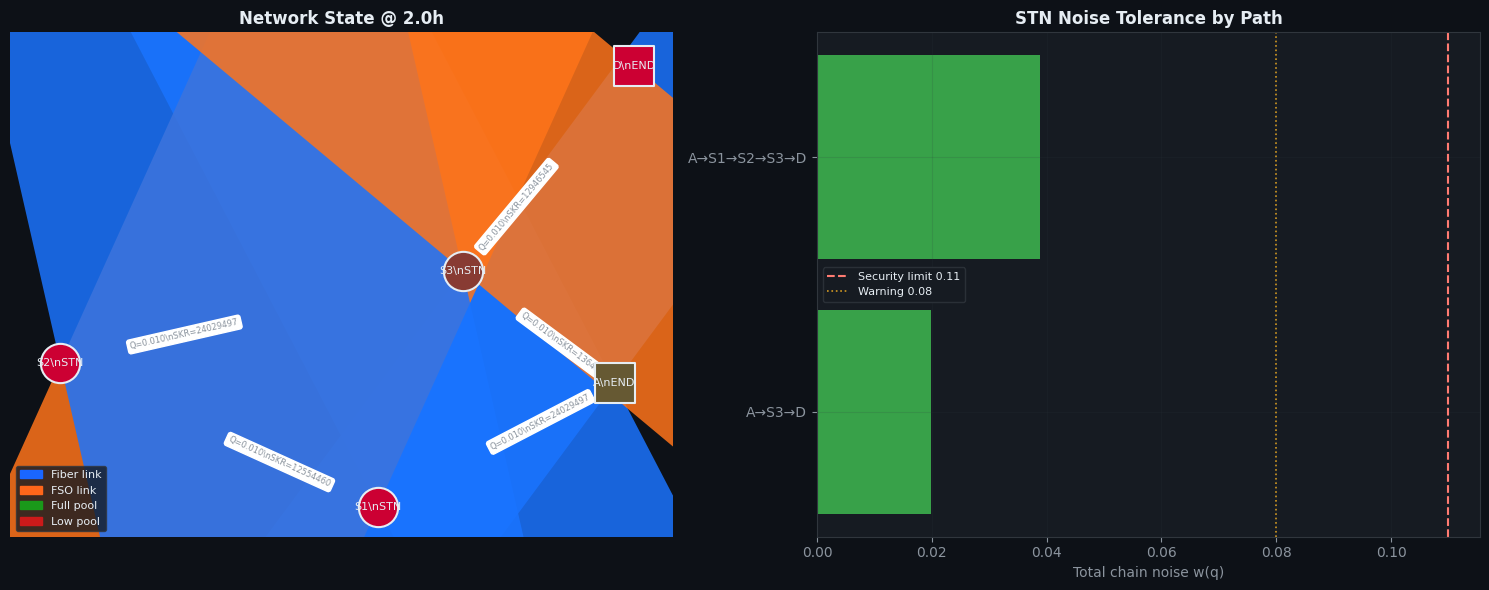

  ✓ Network state @ 2h plotted


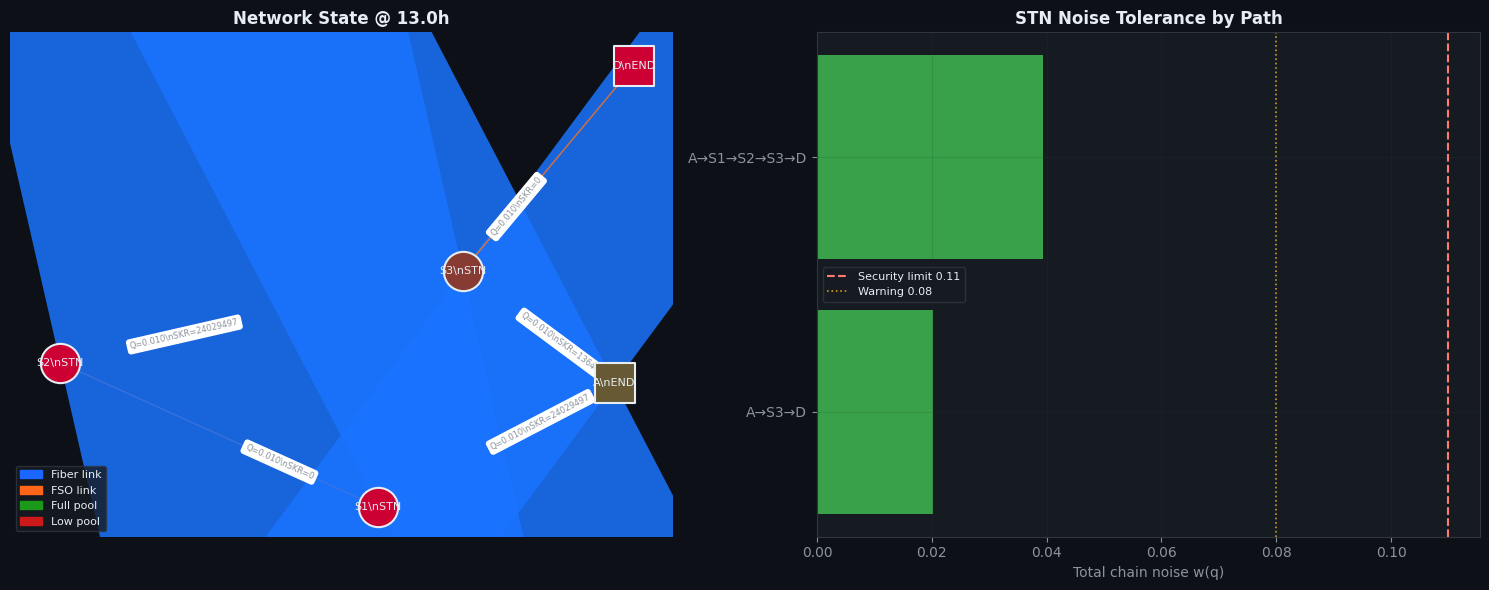

  ✓ Network state @ 13h plotted


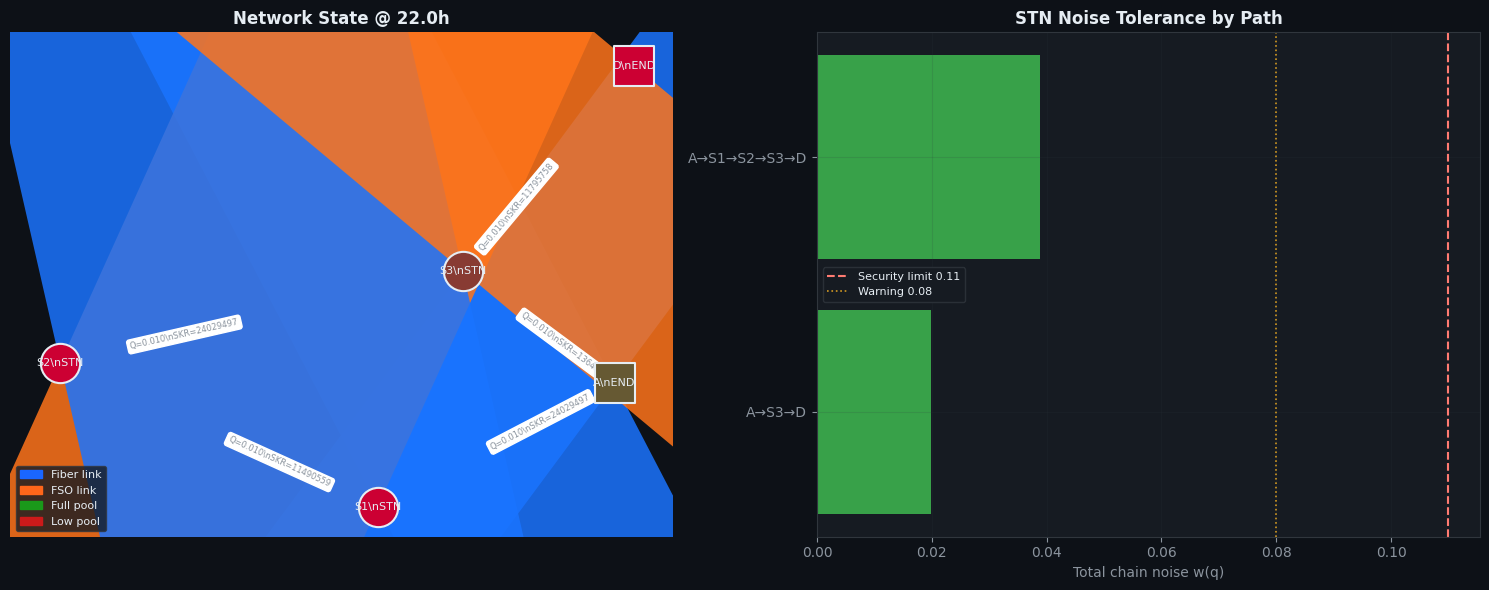

  ✓ Network state @ 22h plotted


In [ ]:
def plot_network_state(network, time_h=0., eval_model=None):
    """
    Draw the QKD network with live link states.
    Node colour: pool health (green=full, red=empty)
    Edge colour: link type + QBER (blue=fiber, orange=FSO)
    Edge width:  proportional to SKR
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                              facecolor="#0d1117")
    G = network.graph
    pos = nx.spring_layout(G, seed=42, k=1.5)

    # Sample physics at requested time
    t_sec = time_h * 3600
    state = network.get_state(t_sec)

    # ── Left: network topology ────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor("#0d1117")
    ax.set_title(f"Network State @ {time_h:.1f}h",
                 color="#e6edf3", fontsize=12, fontweight="bold")

    # Node colours by pool health
    node_colors = []
    for node in G.nodes():
        inc = [(i,node) for i in G.nodes() if G.has_edge(i,node)]
        pools_n = [network.key_pools.get(lk,
                   network.key_pools.get((lk[1],lk[0]),
                   network.pool_capacity)) for lk in inc]
        pr = np.mean(pools_n)/network.pool_capacity if pools_n else 1.
        r  = 1-pr; g = pr
        node_colors.append((r*0.8, g*0.7, 0.2))

    ntype_labels = network.config['node_types']
    node_shapes  = {"endpoint":"s","stn":"o","full_tn":"D"}

    for node, nc in zip(G.nodes(), node_colors):
        ns  = node_shapes.get(ntype_labels.get(node,"stn"), "o")
        nx.draw_networkx_nodes(G, pos, nodelist=[node],
                               node_color=[nc], ax=ax,
                               node_size=800, node_shape=ns,
                               edgecolors="#e6edf3", linewidths=1.5)

    # Edge colours by type and QBER
    for (i,j) in G.edges():
        s    = state.get((i,j), state.get((j,i),{}))
        qber = s.get("QBER",0.)
        skr  = s.get("SKR",0.)
        ltype= network.links.get((i,j),network.links.get((j,i),None))
        is_fso = ltype and ltype.link_type()=="fso"

        # Color: blue=fiber, orange=FSO; darken if QBER high
        if is_fso:
            c = (1.0, 0.5*(1-qber/0.11), 0.1)
        else:
            c = (0.1, 0.5*(1-qber/0.11), 1.0)

        width = max(1., 4. * skr / max(MAX_SKR, 1.))
        nx.draw_networkx_edges(G, pos, edgelist=[(i,j)],
                               edge_color=[c], ax=ax,
                               width=width, alpha=0.85,
                               connectionstyle="arc3,rad=0.05")

    # Labels
    labels = {n: f"{n}\\n{ntype_labels.get(n,'?')[:3].upper()}"
              for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax,
                            font_color="#e6edf3", font_size=8)
    # Edge QBER labels
    edge_labels = {}
    for (i,j) in G.edges():
        s    = state.get((i,j), state.get((j,i),{}))
        qber = s.get("QBER",0.)
        skr  = s.get("SKR",0.)
        edge_labels[(i,j)] = f"Q={qber:.3f}\\nSKR={skr:.0f}"
    nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax,
                                 font_size=6, font_color="#8b949e",
                                 label_pos=0.3)
    ax.axis("off")

    # Legend
    leg = [mpatches.Patch(color=(0.1,0.4,1.0), label="Fiber link"),
           mpatches.Patch(color=(1.0,0.4,0.1), label="FSO link"),
           mpatches.Patch(color=(0.1,0.6,0.1), label="Full pool"),
           mpatches.Patch(color=(0.8,0.1,0.1), label="Low pool")]
    ax.legend(handles=leg, fontsize=8, facecolor="#161b22",
              labelcolor="#e6edf3", edgecolor="#30363d",
              loc="lower left")

    # ── Right: STN noise tolerance chart ─────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor("#161b22")
    ax2.set_title("STN Noise Tolerance by Path",
                  color="#e6edf3", fontsize=12, fontweight="bold")
    ax2.tick_params(colors="#8b949e"); ax2.grid(alpha=0.15, color="#30363d")
    for spine in ax2.spines.values(): spine.set_edgecolor("#30363d")

    path_labels, path_wqs, path_colors = [], [], []
    for path in network.candidate_paths:
        n_stn = sum(1 for n in path[1:-1]
                    if network.config["node_types"].get(n,"stn")=="stn")
        # Get mean QBER along path
        plinks = [(path[k],path[k+1]) for k in range(len(path)-1)]
        q_vals = [state.get(lk, state.get((lk[1],lk[0]),{})).get("QBER",0.04)
                  for lk in plinks]
        Q_mean = np.mean(q_vals)
        wq = total_chain_noise(Q_mean, n_stn)
        label = "→".join(path)
        path_labels.append(label)
        path_wqs.append(wq)
        sec = wq < 0.11
        path_colors.append("#3fb950" if sec else "#ff7b72")

    bars = ax2.barh(path_labels, path_wqs, color=path_colors, alpha=0.85)
    ax2.axvline(0.11, color="#ff7b72", ls="--", lw=1.5, label="Security limit 0.11")
    ax2.axvline(0.08, color="#d29922", ls=":", lw=1.2, label="Warning 0.08")
    ax2.set_xlabel("Total chain noise w(q)", color="#8b949e")
    ax2.legend(fontsize=8, facecolor="#161b22", labelcolor="#e6edf3",
               edgecolor="#30363d")

    plt.tight_layout()
    plt.savefig(f"network_state_{time_h:.0f}h.png", dpi=140,
                bbox_inches="tight", facecolor="#0d1117")
    plt.show()

# Show network at three key times
for h in [2.0, 13.0, 22.0]:
    plot_network_state(net, time_h=h)
    print(f"  \u2713 Network state @ {h:.0f}h plotted")

  Random    : -659.448 ± 376.858
  Shortest  : -6433.871 ± 0.000
  Max-SKR   : -195.180 ± 0.000
  PPO+GNN   : -195.180 ± 0.000


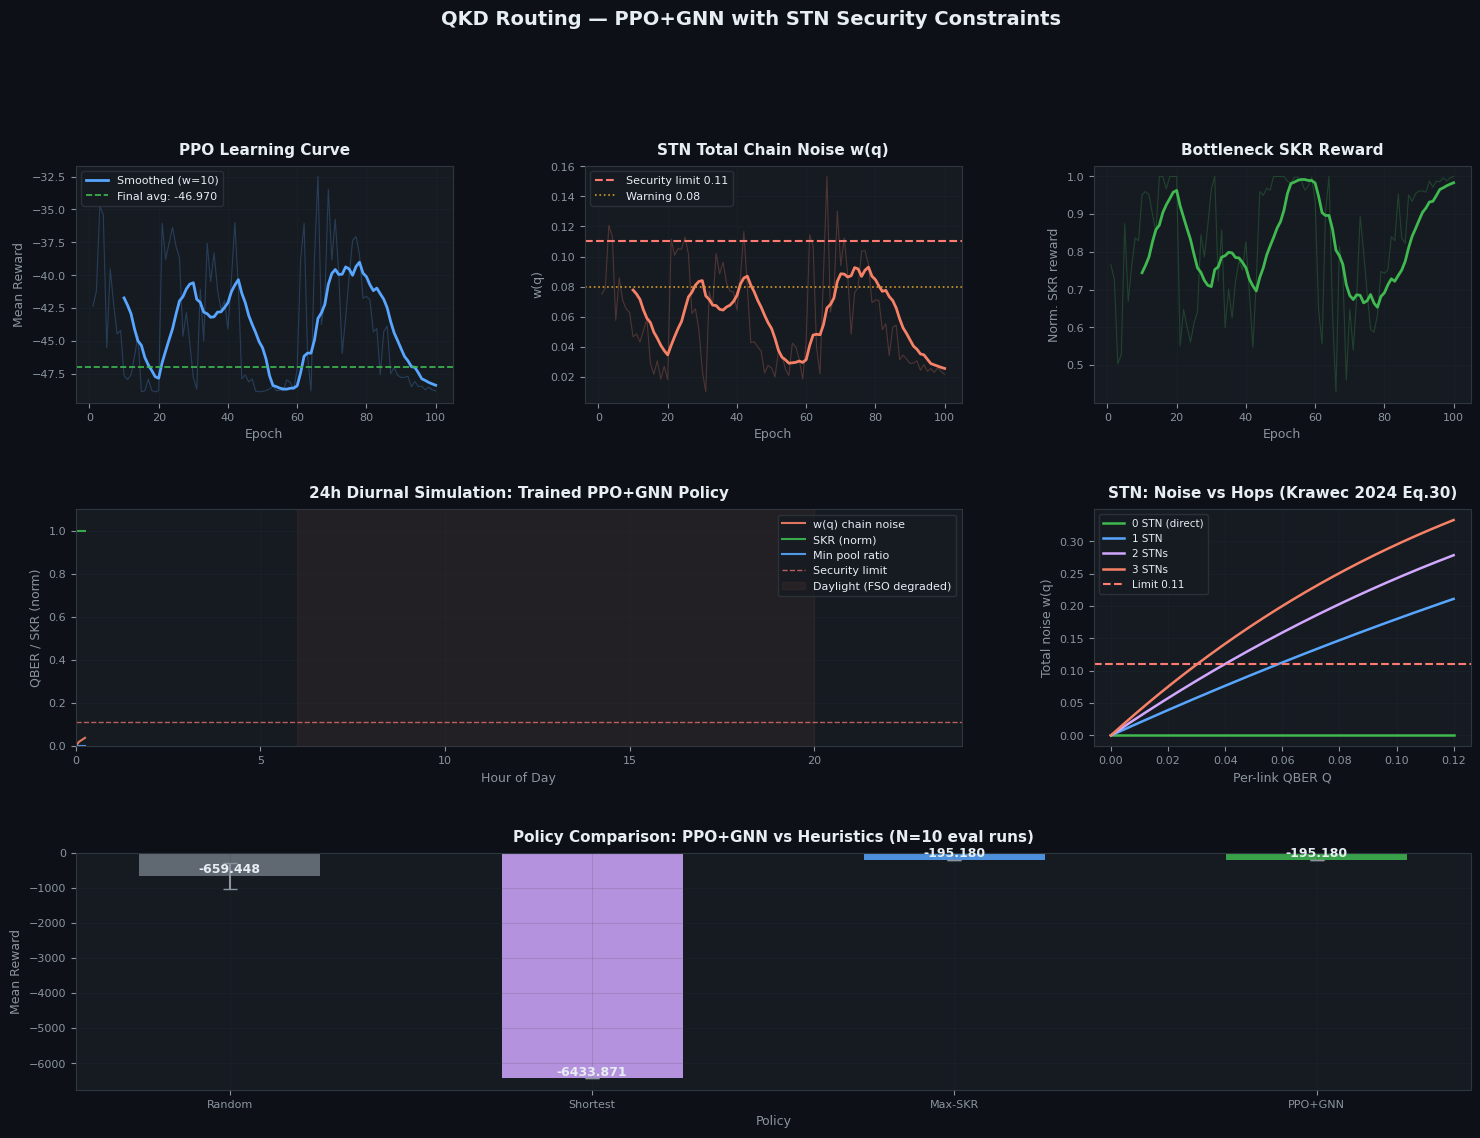


✓ Results plotted and saved to qkd_ppo_results.png


In [ ]:
def smooth(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0d1117")
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

def ax_style(ax, title, xlabel, ylabel):
    ax.set_facecolor("#161b22")
    ax.set_title(title, color="#e6edf3", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, color="#8b949e", fontsize=9)
    ax.set_ylabel(ylabel, color="#8b949e", fontsize=9)
    ax.tick_params(colors="#8b949e", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.grid(alpha=0.15, color="#30363d")
    return ax

epochs = np.arange(1, len(logs["rewards"])+1)
w = 10   # smoothing window

# ── (0,0) Reward learning curve ──────────────────────────────────────────────
ax = ax_style(fig.add_subplot(gs[0,0]),
              "PPO Learning Curve", "Epoch", "Mean Reward")
ax.plot(epochs, logs["rewards"], alpha=0.25, color="#58a6ff", lw=0.8)
ax.plot(epochs[w-1:], smooth(logs["rewards"],w),
        color="#58a6ff", lw=2, label="Smoothed (w=10)")
ax.axhline(np.mean(logs["rewards"][-20:]), color="#3fb950",
           ls="--", lw=1.2, label=f"Final avg: {np.mean(logs['rewards'][-20:]):.3f}")
ax.legend(fontsize=8, facecolor="#161b22", labelcolor="#e6edf3",
          edgecolor="#30363d")

# ── (0,1) STN chain noise w(q) ────────────────────────────────────────────────
ax = ax_style(fig.add_subplot(gs[0,1]),
              "STN Total Chain Noise w(q)", "Epoch", "w(q)")
ax.plot(epochs, logs["wq"], alpha=0.25, color="#f78166", lw=0.8)
ax.plot(epochs[w-1:], smooth(logs["wq"],w),
        color="#f78166", lw=2)
ax.axhline(0.11, color="#ff7b72", ls="--", lw=1.5, label="Security limit 0.11")
ax.axhline(0.08, color="#d29922", ls=":", lw=1.2, label="Warning 0.08")
ax.legend(fontsize=8, facecolor="#161b22", labelcolor="#e6edf3",
          edgecolor="#30363d")

# ── (0,2) SKR reward term ─────────────────────────────────────────────────────
ax = ax_style(fig.add_subplot(gs[0,2]),
              "Bottleneck SKR Reward", "Epoch", "Norm. SKR reward")
ax.plot(epochs, logs["skr"], alpha=0.25, color="#3fb950", lw=0.8)
ax.plot(epochs[w-1:], smooth(logs["skr"],w),
        color="#3fb950", lw=2)

# ── (1,0-1) Diurnal simulation ────────────────────────────────────────────────
ax_d = ax_style(fig.add_subplot(gs[1,:2]),
                "24h Diurnal Simulation: Trained PPO+GNN Policy",
                "Hour of Day", "QBER / SKR (norm)")

env_eval = QKDRoutingEnv(net, use_case=USE_CASE)
obs, _ = env_eval.reset()
hours, qbers, skrs_eval, pools_eval, wqs_eval = [], [], [], [], []

model.eval()
with torch.no_grad():
    for step in range(env_eval.max_steps):
        nx_, ei, ea = env_eval.get_graph_data()
        cur_idx = env_eval.node2idx[env_eval._cur_node]
        nb_idxs = [env_eval.node2idx[n] for n in env_eval.adj[env_eval._cur_node]]
        if not nb_idxs:
            obs, _ = env_eval.reset(); continue
        action, _, _, _ = model.get_action(nx_, ei, ea, cur_idx, nb_idxs,
                                           deterministic=True)
        obs, reward, terminated, truncated, info = env_eval.step(action)

        hours.append(info.get("time_h", step*5/60))
        wqs_eval.append(info.get("w_q", 0.))
        skrs_eval.append(info.get("skr", 0.))
        pools_eval.append(info.get("pool", 1.))

        if terminated or truncated:
            break

ax_d.plot(hours, wqs_eval, color="#f78166", lw=1.5, label="w(q) chain noise",
          alpha=0.9)
ax_d.plot(hours, skrs_eval, color="#3fb950", lw=1.5, label="SKR (norm)",
          alpha=0.9)
ax_d.plot(hours, pools_eval, color="#58a6ff", lw=1.5, label="Min pool ratio",
          alpha=0.9)
ax_d.axhline(0.11, color="#ff7b72", ls="--", lw=1, alpha=0.7,
             label="Security limit")
ax_d.fill_betweenx([0,1.1], 6, 20, alpha=0.06, color="#f78166",
                   label="Daylight (FSO degraded)")
ax_d.set_xlim(0, 24)
ax_d.set_ylim(0, 1.1)
ax_d.legend(fontsize=8, facecolor="#161b22", labelcolor="#e6edf3",
            edgecolor="#30363d", loc="upper right")

# ── (1,2) STN noise vs hops ───────────────────────────────────────────────────
ax_n = ax_style(fig.add_subplot(gs[1,2]),
                "STN: Noise vs Hops (Krawec 2024 Eq.30)",
                "Per-link QBER Q", "Total noise w(q)")
Q_range = np.linspace(0, 0.12, 200)
for p, col, lbl in [(0,"#3fb950","0 STN (direct)"),
                    (1,"#58a6ff","1 STN"),
                    (2,"#d2a8ff","2 STNs"),
                    (3,"#f78166","3 STNs")]:
    wqs = [total_chain_noise(Q, p) for Q in Q_range]
    ax_n.plot(Q_range, wqs, color=col, lw=1.8, label=lbl)
ax_n.axhline(0.11, color="#ff7b72", ls="--", lw=1.5, label="Limit 0.11")
ax_n.legend(fontsize=7.5, facecolor="#161b22", labelcolor="#e6edf3",
            edgecolor="#30363d")

# ── (2,:) Policy comparison bar chart ─────────────────────────────────────────
ax_c = ax_style(fig.add_subplot(gs[2,:]),
                "Policy Comparison: PPO+GNN vs Heuristics (N=10 eval runs)",
                "Policy", "Mean Reward")

policies = {
    "random":     lambda nb: np.random.randint(len(nb)),
    "shortest":   lambda nb: 0,    # always take first (shortest) neighbour
    "max_skr":    lambda nb: 0,    # placeholder, uses SKR ranking below
    "PPO+GNN":    None,
}

def eval_policy(policy_fn, n_runs=10, deterministic=False):
    results = []
    for seed in range(n_runs):
        np.random.seed(seed)
        e = QKDRoutingEnv(net, use_case=USE_CASE)
        obs, _ = e.reset()
        total_r = 0.
        for _ in range(min(288, e.max_steps)):
            nx_, ei, ea = e.get_graph_data()
            cur_idx = e.node2idx[e._cur_node]
            nb_idxs = [e.node2idx[n] for n in e.adj[e._cur_node]]
            if not nb_idxs: break

            if policy_fn is None:
                with torch.no_grad():
                    action, _, _, _ = model.get_action(
                        nx_, ei, ea, cur_idx, nb_idxs, deterministic=True)
            else:
                action = policy_fn(nb_idxs) % len(nb_idxs)

            obs, r, term, trunc, _ = e.step(action)
            total_r += r
            if term or trunc: break
        results.append(total_r)
    return np.mean(results), np.std(results)

# Max-SKR policy: pick neighbour with best SKR on connecting link
def max_skr_policy(nb_idxs_):
    cur = env_eval._cur_node
    ns  = env_eval.adj[cur]
    if not ns: return 0
    best = max(range(len(ns)),
               key=lambda i: env_eval.net.key_pools.get(
                   (cur, ns[i]),
                   env_eval.net.key_pools.get((ns[i], cur), 0)))
    return best % len(nb_idxs_)

policy_fns = {
    "Random":   lambda nb: np.random.randint(len(nb)),
    "Shortest": lambda nb: 0,
    "Max-SKR":  max_skr_policy,
    "PPO+GNN":  None,
}

colors_ = {"Random":"#6e7681","Shortest":"#d2a8ff",
           "Max-SKR":"#58a6ff","PPO+GNN":"#3fb950"}
means_, stds_, names_ = [], [], []
for name, fn in policy_fns.items():
    m, s = eval_policy(fn, n_runs=10)
    means_.append(m); stds_.append(s); names_.append(name)
    print(f"  {name:10s}: {m:+7.3f} \u00b1 {s:.3f}")

bars = ax_c.bar(names_, means_,
                color=[colors_[n] for n in names_],
                alpha=0.85, width=0.5,
                yerr=stds_, capsize=5,
                error_kw=dict(ecolor="#8b949e", lw=1.5))
for bar, m in zip(bars, means_):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
              f"{m:+.3f}", ha="center", va="bottom",
              color="#e6edf3", fontsize=9, fontweight="bold")

plt.suptitle("QKD Routing \u2014 PPO+GNN with STN Security Constraints",
             color="#e6edf3", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("qkd_ppo_results.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("\n\u2713 Results plotted and saved to qkd_ppo_results.png")

  Random    : -659.448 ± 376.858
  Shortest  : -6433.871 ± 0.000
  Max-SKR   : -195.180 ± 0.000
  PPO+GNN   : -195.180 ± 0.000


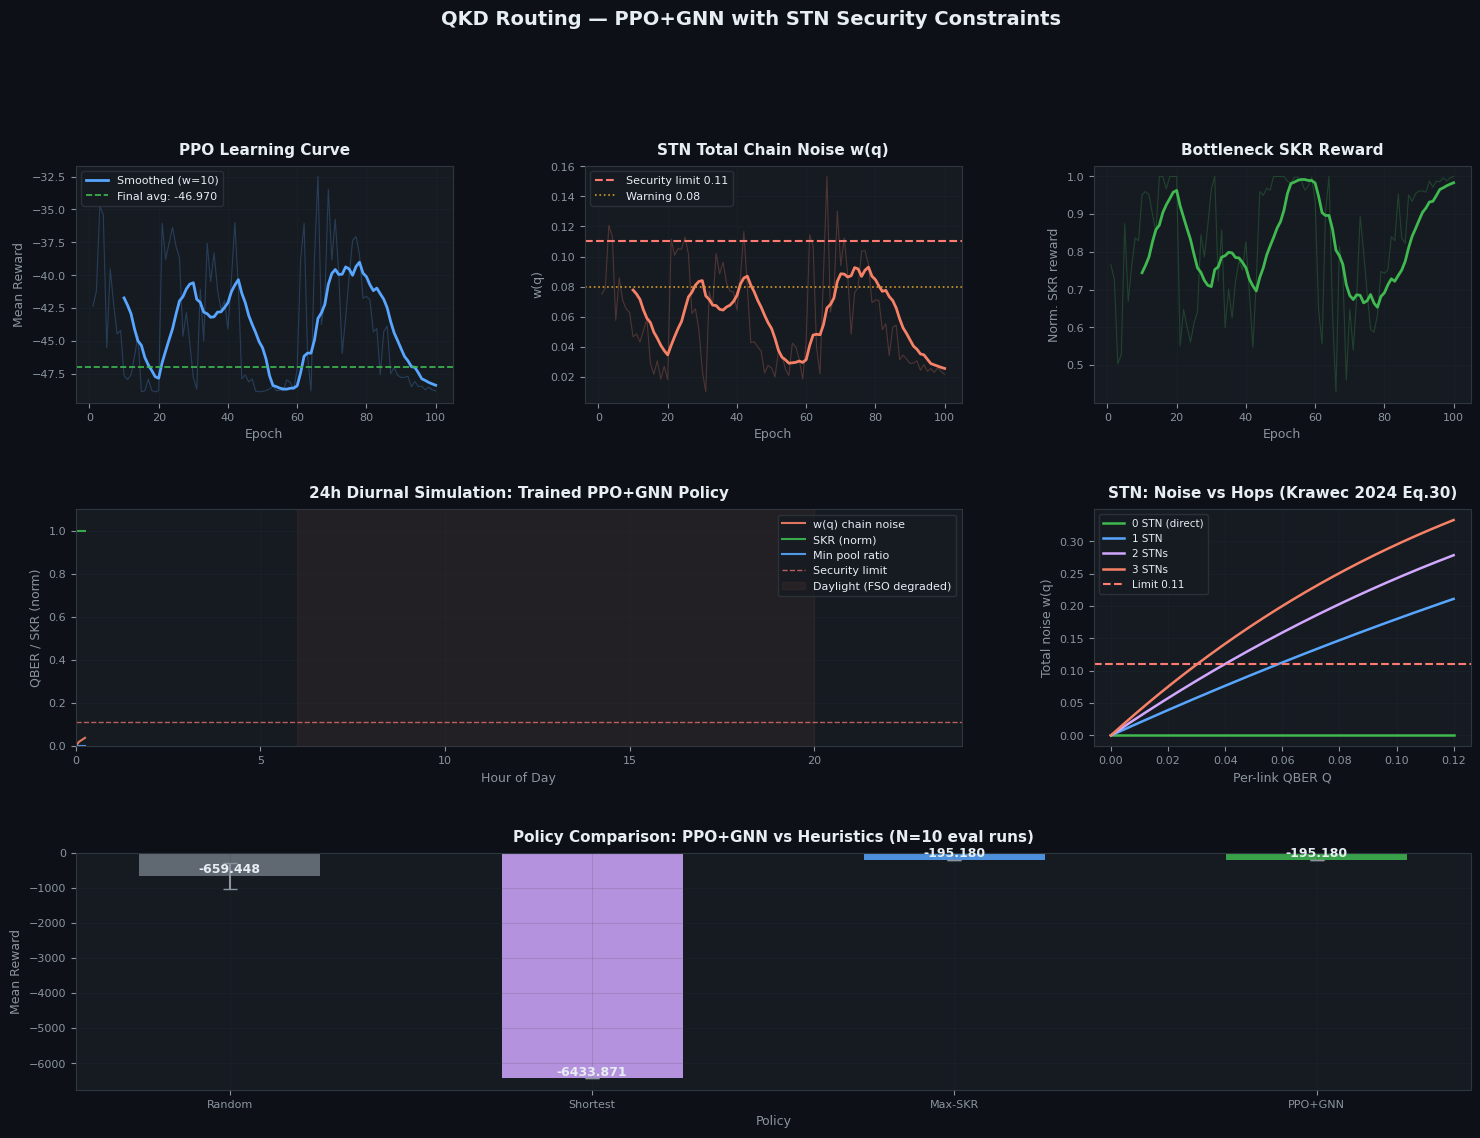


✓ Results plotted and saved to qkd_ppo_results.png


In [ ]:
def smooth(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0d1117")
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

def ax_style(ax, title, xlabel, ylabel):
    ax.set_facecolor("#161b22")
    ax.set_title(title, color="#e6edf3", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, color="#8b949e", fontsize=9)
    ax.set_ylabel(ylabel, color="#8b949e", fontsize=9)
    ax.tick_params(colors="#8b949e", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.grid(alpha=0.15, color="#30363d")
    return ax

epochs = np.arange(1, len(logs["rewards"])+1)
w = 10   # smoothing window

# ── (0,0) Reward learning curve ──────────────────────────────────────────────
ax = ax_style(fig.add_subplot(gs[0,0]),
              "PPO Learning Curve", "Epoch", "Mean Reward")
ax.plot(epochs, logs["rewards"], alpha=0.25, color="#58a6ff", lw=0.8)
ax.plot(epochs[w-1:], smooth(logs["rewards"],w),
        color="#58a6ff", lw=2, label="Smoothed (w=10)")
ax.axhline(np.mean(logs["rewards"][-20:]), color="#3fb950",
           ls="--", lw=1.2, label=f"Final avg: {np.mean(logs['rewards'][-20:]):.3f}")
ax.legend(fontsize=8, facecolor="#161b22", labelcolor="#e6edf3",
          edgecolor="#30363d")

# ── (0,1) STN chain noise w(q) ────────────────────────────────────────────────
ax = ax_style(fig.add_subplot(gs[0,1]),
              "STN Total Chain Noise w(q)", "Epoch", "w(q)")
ax.plot(epochs, logs["wq"], alpha=0.25, color="#f78166", lw=0.8)
ax.plot(epochs[w-1:], smooth(logs["wq"],w),
        color="#f78166", lw=2)
ax.axhline(0.11, color="#ff7b72", ls="--", lw=1.5, label="Security limit 0.11")
ax.axhline(0.08, color="#d29922", ls=":", lw=1.2, label="Warning 0.08")
ax.legend(fontsize=8, facecolor="#161b22", labelcolor="#e6edf3",
          edgecolor="#30363d")

# ── (0,2) SKR reward term ─────────────────────────────────────────────────────
ax = ax_style(fig.add_subplot(gs[0,2]),
              "Bottleneck SKR Reward", "Epoch", "Norm. SKR reward")
ax.plot(epochs, logs["skr"], alpha=0.25, color="#3fb950", lw=0.8)
ax.plot(epochs[w-1:], smooth(logs["skr"],w),
        color="#3fb950", lw=2)

# ── (1,0-1) Diurnal simulation ────────────────────────────────────────────────
ax_d = ax_style(fig.add_subplot(gs[1,:2]),
                "24h Diurnal Simulation: Trained PPO+GNN Policy",
                "Hour of Day", "QBER / SKR (norm)")

env_eval = QKDRoutingEnv(net, use_case=USE_CASE)
obs, _ = env_eval.reset()
hours, qbers, skrs_eval, pools_eval, wqs_eval = [], [], [], [], []

model.eval()
with torch.no_grad():
    for step in range(env_eval.max_steps):
        nx_, ei, ea = env_eval.get_graph_data()
        cur_idx = env_eval.node2idx[env_eval._cur_node]
        nb_idxs = [env_eval.node2idx[n] for n in env_eval.adj[env_eval._cur_node]]
        if not nb_idxs:
            obs, _ = env_eval.reset(); continue
        action, _, _, _ = model.get_action(nx_, ei, ea, cur_idx, nb_idxs,
                                           deterministic=True)
        obs, reward, terminated, truncated, info = env_eval.step(action)

        hours.append(info.get("time_h", step*5/60))
        wqs_eval.append(info.get("w_q", 0.))
        skrs_eval.append(info.get("skr", 0.))
        pools_eval.append(info.get("pool", 1.))

        if terminated or truncated:
            break

ax_d.plot(hours, wqs_eval, color="#f78166", lw=1.5, label="w(q) chain noise",
          alpha=0.9)
ax_d.plot(hours, skrs_eval, color="#3fb950", lw=1.5, label="SKR (norm)",
          alpha=0.9)
ax_d.plot(hours, pools_eval, color="#58a6ff", lw=1.5, label="Min pool ratio",
          alpha=0.9)
ax_d.axhline(0.11, color="#ff7b72", ls="--", lw=1, alpha=0.7,
             label="Security limit")
ax_d.fill_betweenx([0,1.1], 6, 20, alpha=0.06, color="#f78166",
                   label="Daylight (FSO degraded)")
ax_d.set_xlim(0, 24)
ax_d.set_ylim(0, 1.1)
ax_d.legend(fontsize=8, facecolor="#161b22", labelcolor="#e6edf3",
            edgecolor="#30363d", loc="upper right")

# ── (1,2) STN noise vs hops ───────────────────────────────────────────────────
ax_n = ax_style(fig.add_subplot(gs[1,2]),
                "STN: Noise vs Hops (Krawec 2024 Eq.30)",
                "Per-link QBER Q", "Total noise w(q)")
Q_range = np.linspace(0, 0.12, 200)
for p, col, lbl in [(0,"#3fb950","0 STN (direct)"),
                    (1,"#58a6ff","1 STN"),
                    (2,"#d2a8ff","2 STNs"),
                    (3,"#f78166","3 STNs")]:
    wqs = [total_chain_noise(Q, p) for Q in Q_range]
    ax_n.plot(Q_range, wqs, color=col, lw=1.8, label=lbl)
ax_n.axhline(0.11, color="#ff7b72", ls="--", lw=1.5, label="Limit 0.11")
ax_n.legend(fontsize=7.5, facecolor="#161b22", labelcolor="#e6edf3",
            edgecolor="#30363d")

# ── (2,:) Policy comparison bar chart ─────────────────────────────────────────
ax_c = ax_style(fig.add_subplot(gs[2,:]),
                "Policy Comparison: PPO+GNN vs Heuristics (N=10 eval runs)",
                "Policy", "Mean Reward")

policies = {
    "random":     lambda nb: np.random.randint(len(nb)),
    "shortest":   lambda nb: 0,    # always take first (shortest) neighbour
    "max_skr":    lambda nb: 0,    # placeholder, uses SKR ranking below
    "PPO+GNN":    None,
}

def eval_policy(policy_fn, n_runs=10, deterministic=False):
    results = []
    for seed in range(n_runs):
        np.random.seed(seed)
        e = QKDRoutingEnv(net, use_case=USE_CASE)
        obs, _ = e.reset()
        total_r = 0.
        for _ in range(min(288, e.max_steps)):
            nx_, ei, ea = e.get_graph_data()
            cur_idx = e.node2idx[e._cur_node]
            nb_idxs = [e.node2idx[n] for n in e.adj[e._cur_node]]
            if not nb_idxs: break

            if policy_fn is None:
                with torch.no_grad():
                    action, _, _, _ = model.get_action(
                        nx_, ei, ea, cur_idx, nb_idxs, deterministic=True)
            else:
                action = policy_fn(nb_idxs) % len(nb_idxs)

            obs, r, term, trunc, _ = e.step(action)
            total_r += r
            if term or trunc: break
        results.append(total_r)
    return np.mean(results), np.std(results)

# Max-SKR policy: pick neighbour with best SKR on connecting link
def max_skr_policy(nb_idxs_):
    cur = env_eval._cur_node
    ns  = env_eval.adj[cur]
    if not ns: return 0
    best = max(range(len(ns)),
               key=lambda i: env_eval.net.key_pools.get(
                   (cur, ns[i]),
                   env_eval.net.key_pools.get((ns[i], cur), 0)))
    return best % len(nb_idxs_)

policy_fns = {
    "Random":   lambda nb: np.random.randint(len(nb)),
    "Shortest": lambda nb: 0,
    "Max-SKR":  max_skr_policy,
    "PPO+GNN":  None,
}

colors_ = {"Random":"#6e7681","Shortest":"#d2a8ff",
           "Max-SKR":"#58a6ff","PPO+GNN":"#3fb950"}
means_, stds_, names_ = [], [], []
for name, fn in policy_fns.items():
    m, s = eval_policy(fn, n_runs=10)
    means_.append(m); stds_.append(s); names_.append(name)
    print(f"  {name:10s}: {m:+7.3f} \u00b1 {s:.3f}")

bars = ax_c.bar(names_, means_,
                color=[colors_[n] for n in names_],
                alpha=0.85, width=0.5,
                yerr=stds_, capsize=5,
                error_kw=dict(ecolor="#8b949e", lw=1.5))
for bar, m in zip(bars, means_):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
              f"{m:+.3f}", ha="center", va="bottom",
              color="#e6edf3", fontsize=9, fontweight="bold")

plt.suptitle("QKD Routing \u2014 PPO+GNN with STN Security Constraints",
             color="#e6edf3", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("qkd_ppo_results.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("\n\u2713 Results plotted and saved to qkd_ppo_results.png")